# [LAB-08] PBT - EDAㅣ5-EDA 파이프라인(실습코드).ipynb

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 품질 점검 완료 데이터 셋 가져오기 

In [2]:
origin = load_data("diamonds_qtcheck")
num_desc = load_data("diamonds_numerical_summary")
cat_desc = load_data("diamonds_categorical_summary")

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)

📚 다이아몬드 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 다이아몬드 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 3. 타입 변환 (명목형 확정)

In [3]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


### 4. 변수 유형 분류 

In [5]:
# 종속변수 
target = "price"
# 종속변수 연속형 여부 
target_is_continuous = True

# 명목형 변수 
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수 
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous: 
    # 연속형 변수 이름에서 종속변수 항목 제거 
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거 
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형:" + ("연속형" if target_is_continuous else "명목형"))
print("명목형 : ", nominal_cols)
print("연속형 : ", continuous_cols)

종속변수 : price
종속변수 유형:연속형
명목형 :  ['cut', 'color', 'clarity']
연속형 :  ['carat', 'x', 'y', 'z', 'depth', 'table']


### 5. 컬럼 의미를 정리한 딕셔너리 

In [6]:
column_means = {
    "price" : "다이아몬드 가격 (USD)", 
    "carat" : "중량", 
    "cut" : "컷팅 등급", # Fair, Good, Very Good, Premium, Ideal
    "color" : "색상 등급", # J (worst) to D (best)
    "clarity" : "투명도 등급", # (I1 (worst), SI2, SI1, VS2, VVS2, VVS1m, IF(best))
    "x" : "길이(mm)", 
    "y" : "너비 (mm)", 
    "z" : "두께 (mm)", 
    "depth" : "비율 정보", 
    "table" : "테이블 너비"
}

### 6. 서열척도 적용 ( 필요에 따라 수행 )

In [11]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 -> 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다.
ordinal_map = {
    "cut" : ["Fair", "Good", "Very Good", "Premium", "Ideal"], 
    "color" : ["J", "I", "H", "G", "F", "E", "D"], 
    "clarity" : ["I1", "SI2", "SI1", "VS1", "VS2", "VVS2", "VVS1", "IF"],
}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다. 
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


## #02. 단변량 분석 

### 1. 연속형 종속변수에 대한 단변량 분석 

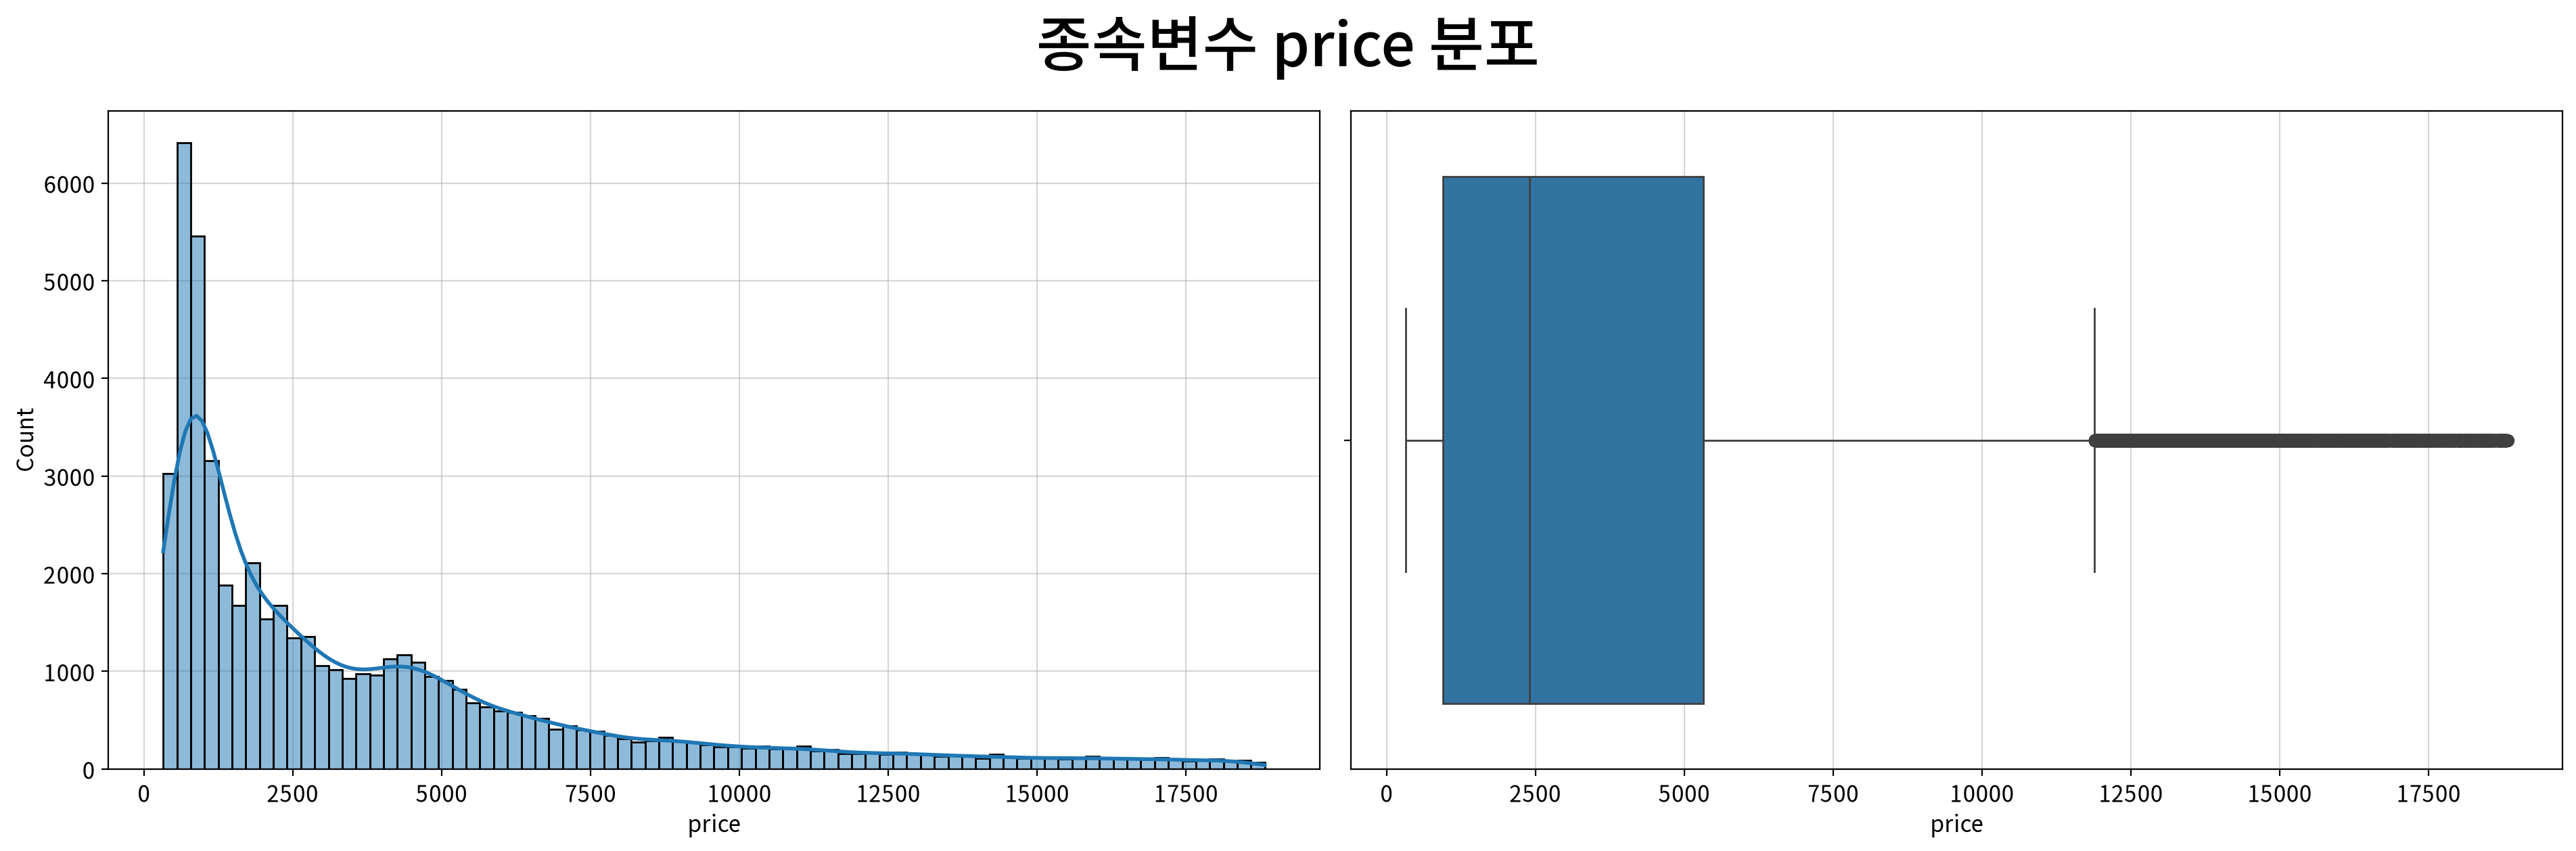

,price
count,53794.000
mean,3933.065
std,3988.114
min,326.000
25%,951.000
50%,2401.000
75%,5326.750
max,18823.000
rel_diff,0.638
rdiff_flag,large_diff


In [ ]:
# 1행 2열 서브플롯 구성 
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 X 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

### 2. 연속형 독립변수에 대한 단변량 분석 

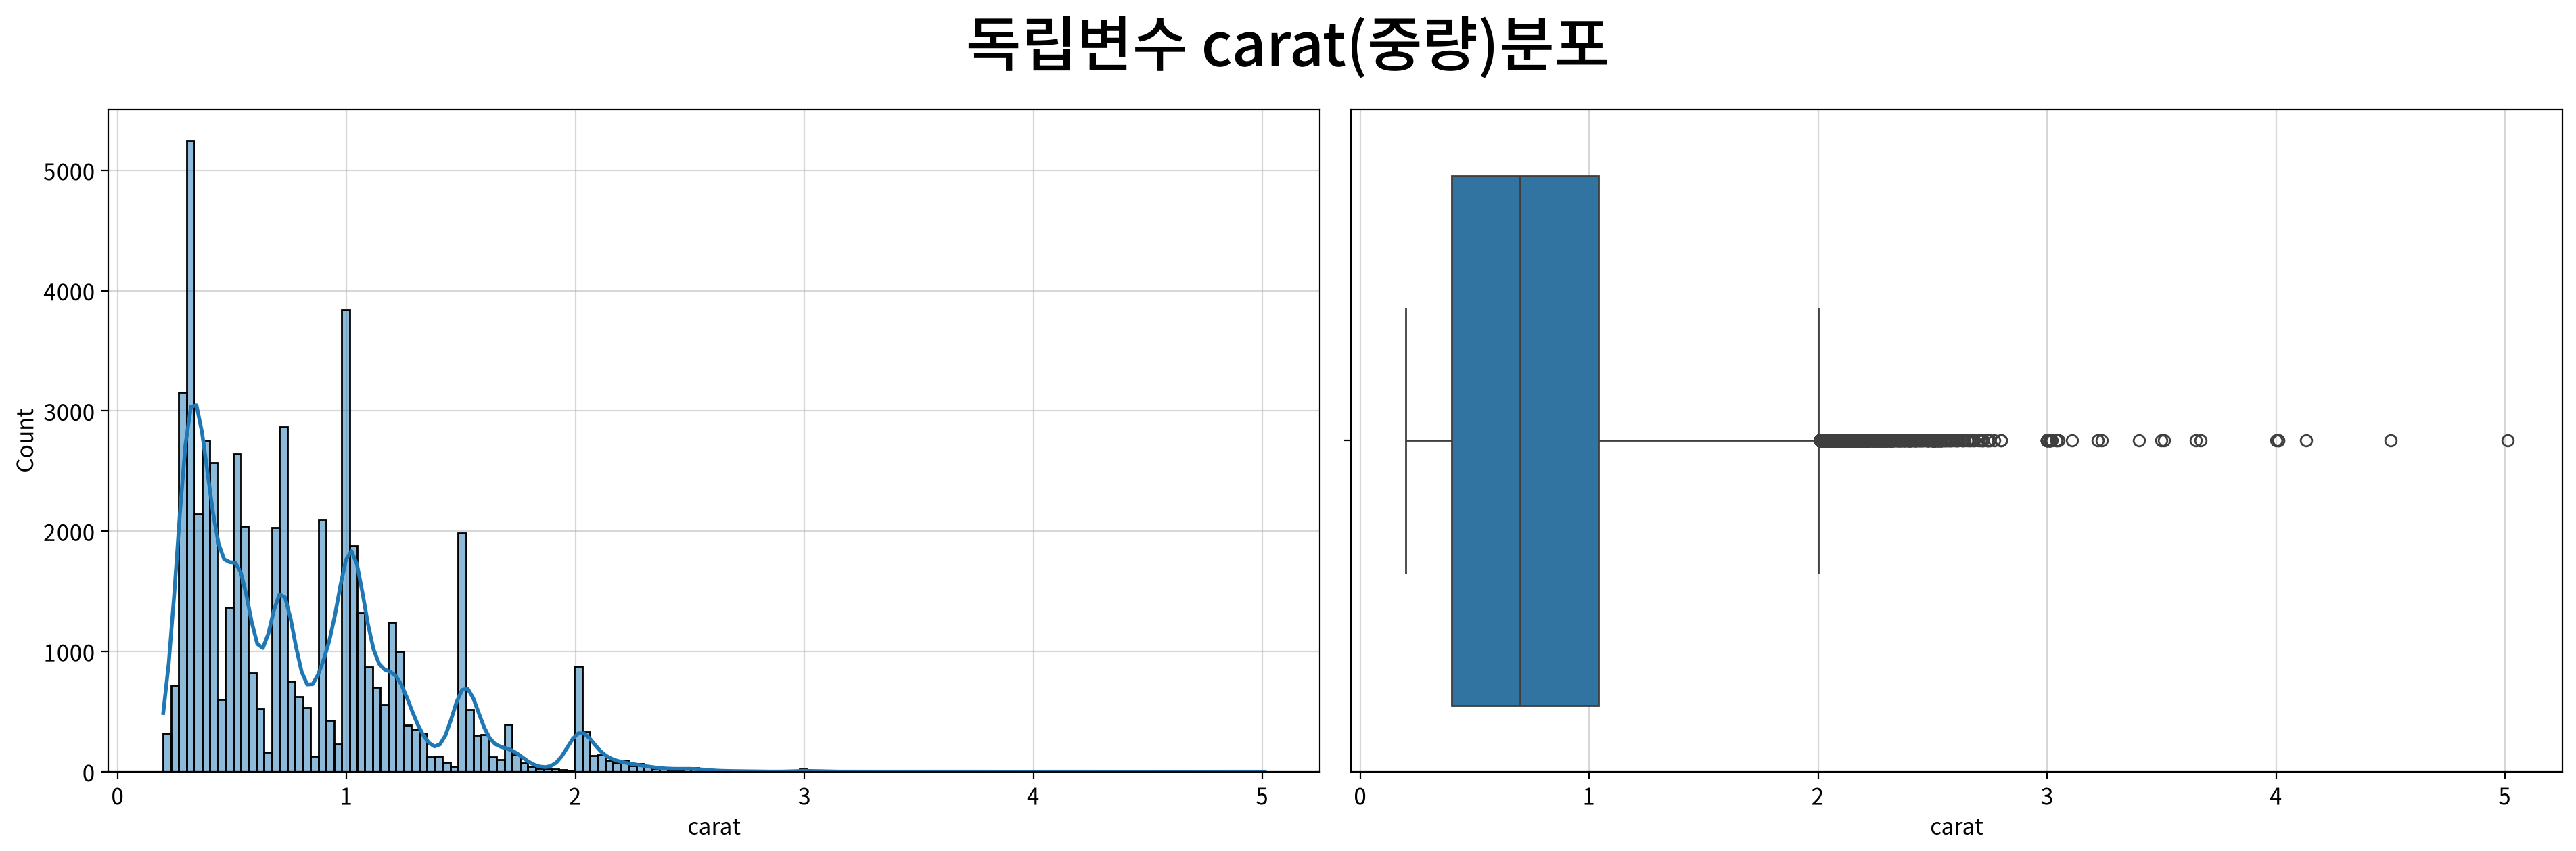

,carat
count,53794.000
mean,0.798
std,0.473
min,0.200
25%,0.400
50%,0.700
75%,1.040
max,5.010
rel_diff,0.140
rdiff_flag,diff


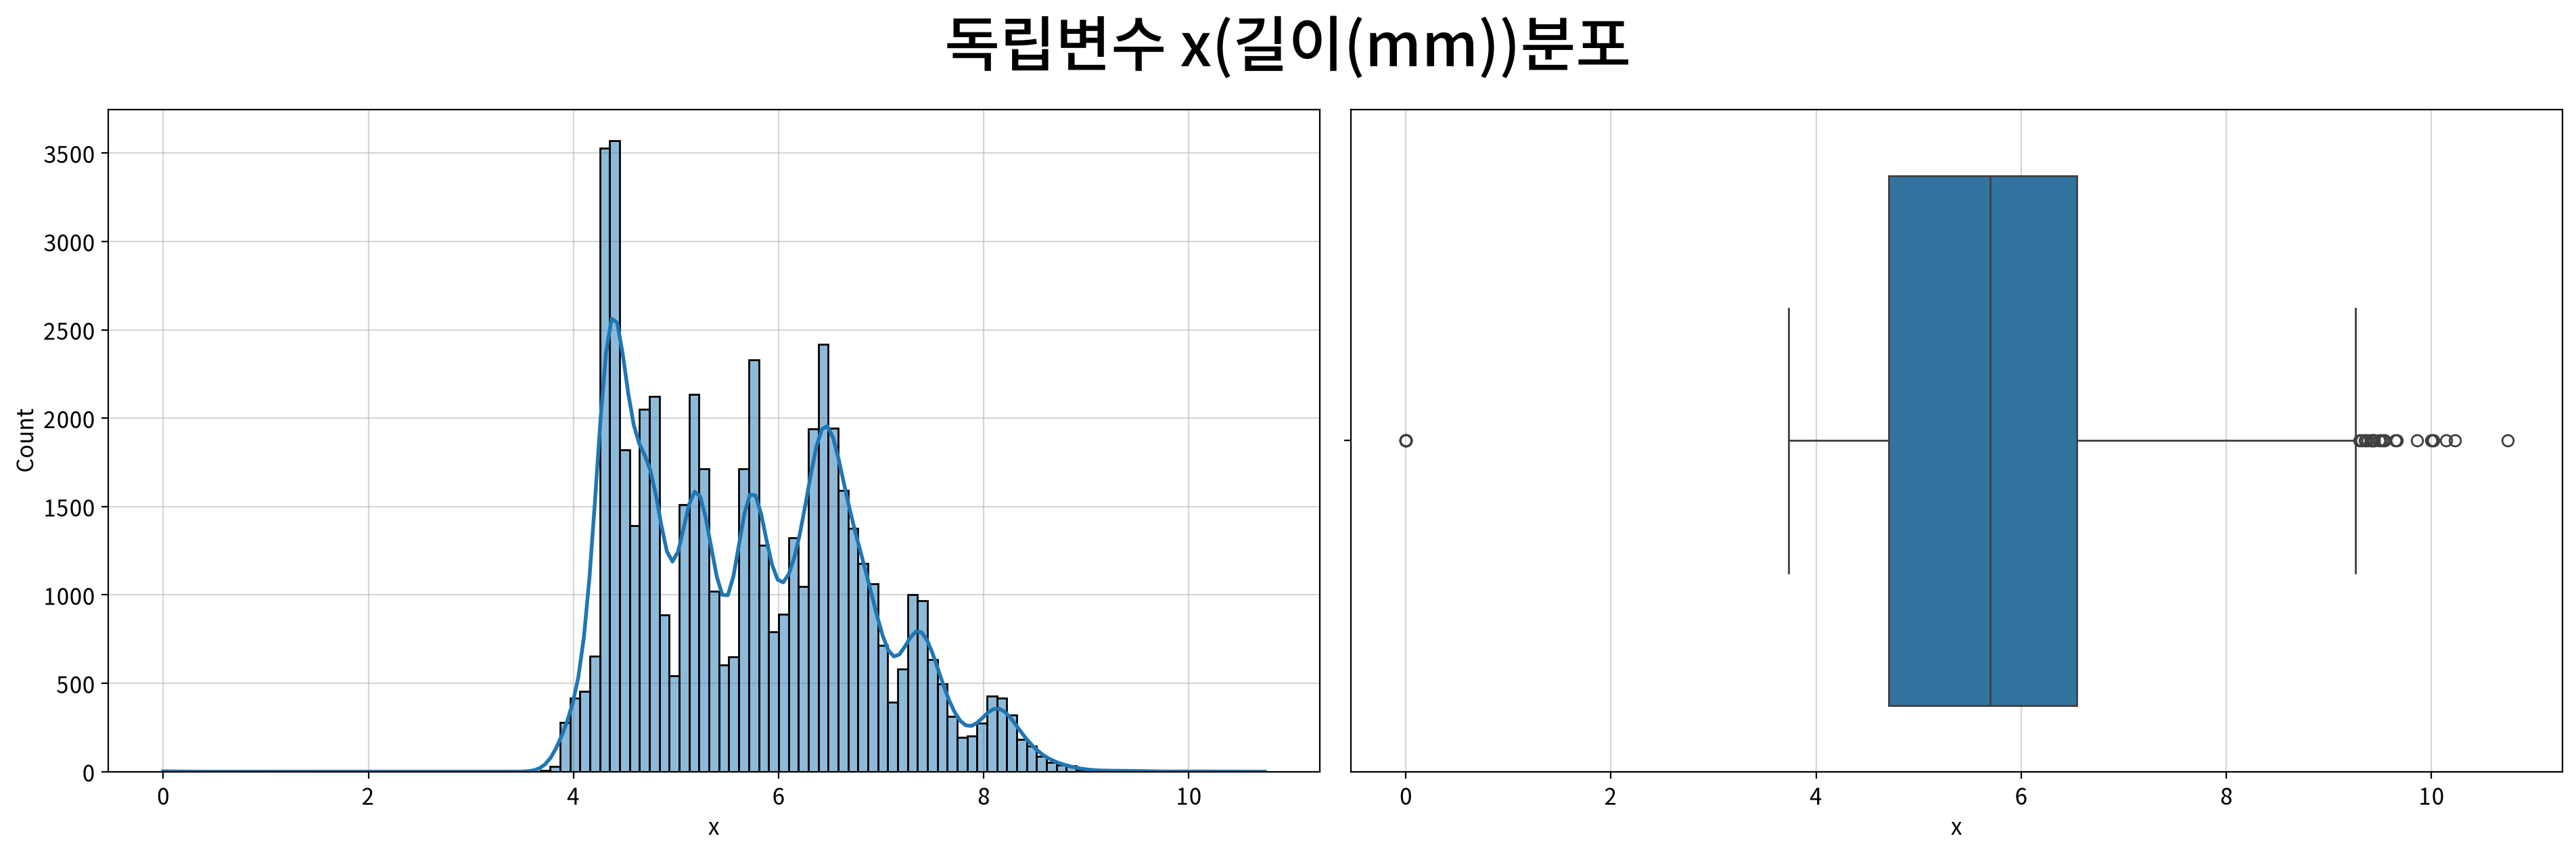

,x
count,53794.000
mean,5.731
std,1.121
min,0.000
25%,4.710
50%,5.700
75%,6.540
max,10.740
rel_diff,0.005
rdiff_flag,similar


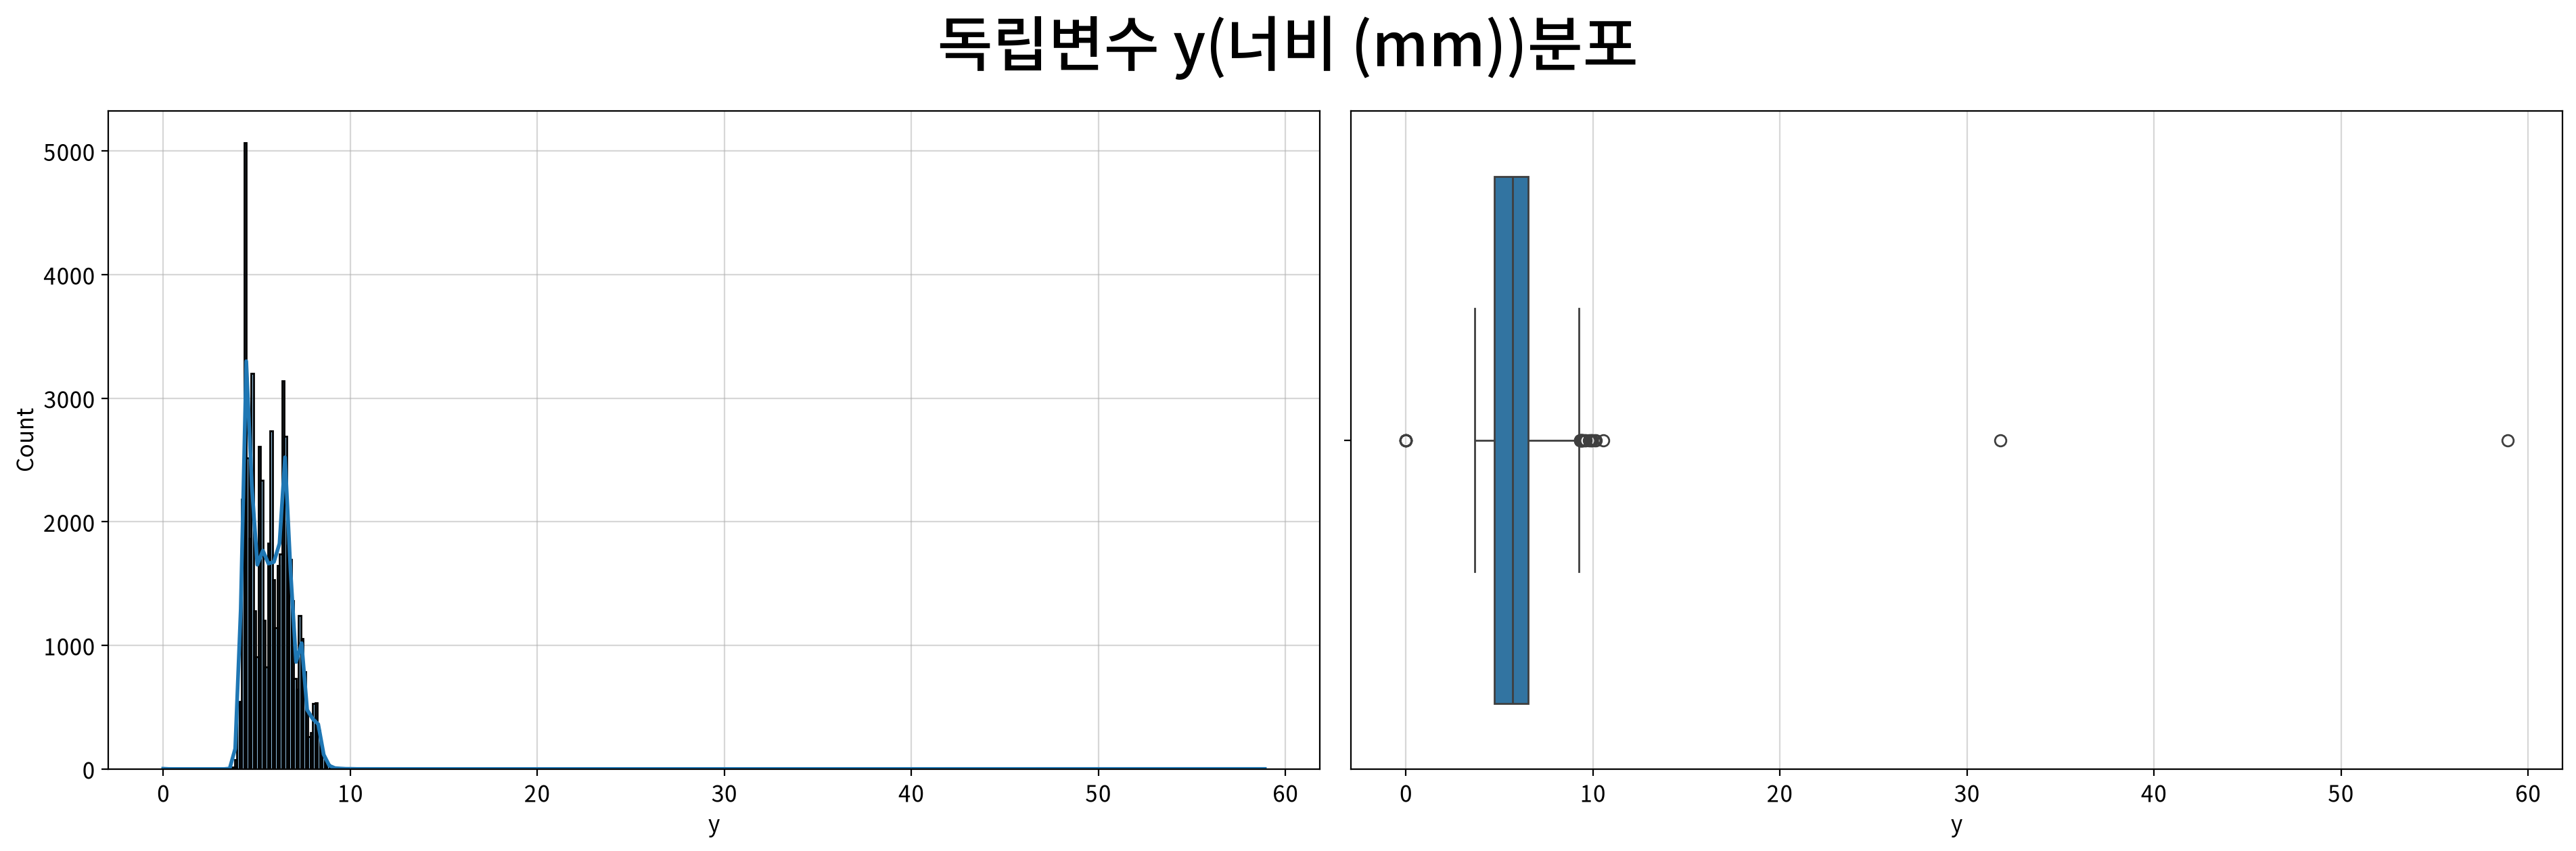

,y
count,53794.000
mean,5.735
std,1.141
min,0.000
25%,4.720
50%,5.710
75%,6.540
max,58.900
rel_diff,0.004
rdiff_flag,similar


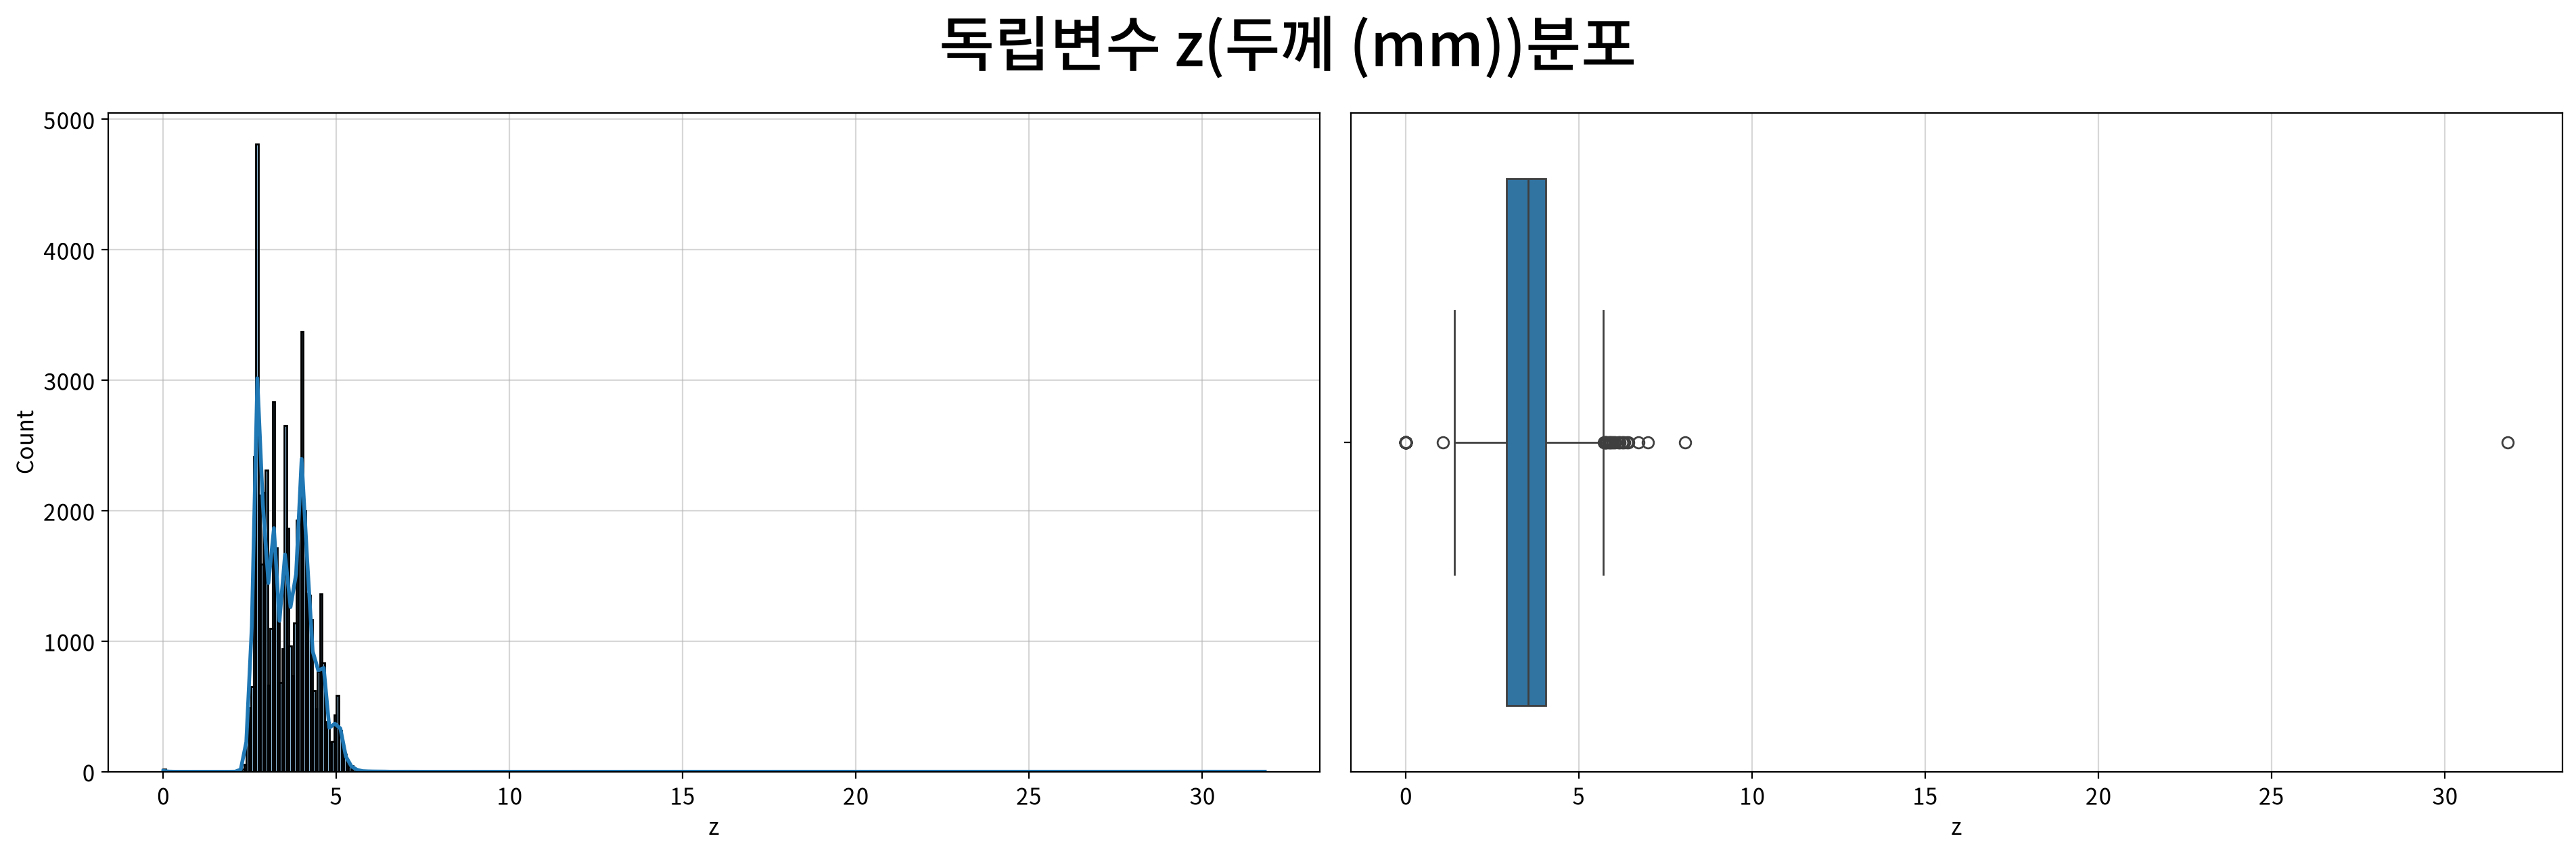

,z
count,53794.000
mean,3.539
std,0.705
min,0.000
25%,2.910
50%,3.530
75%,4.030
max,31.800
rel_diff,0.002
rdiff_flag,similar


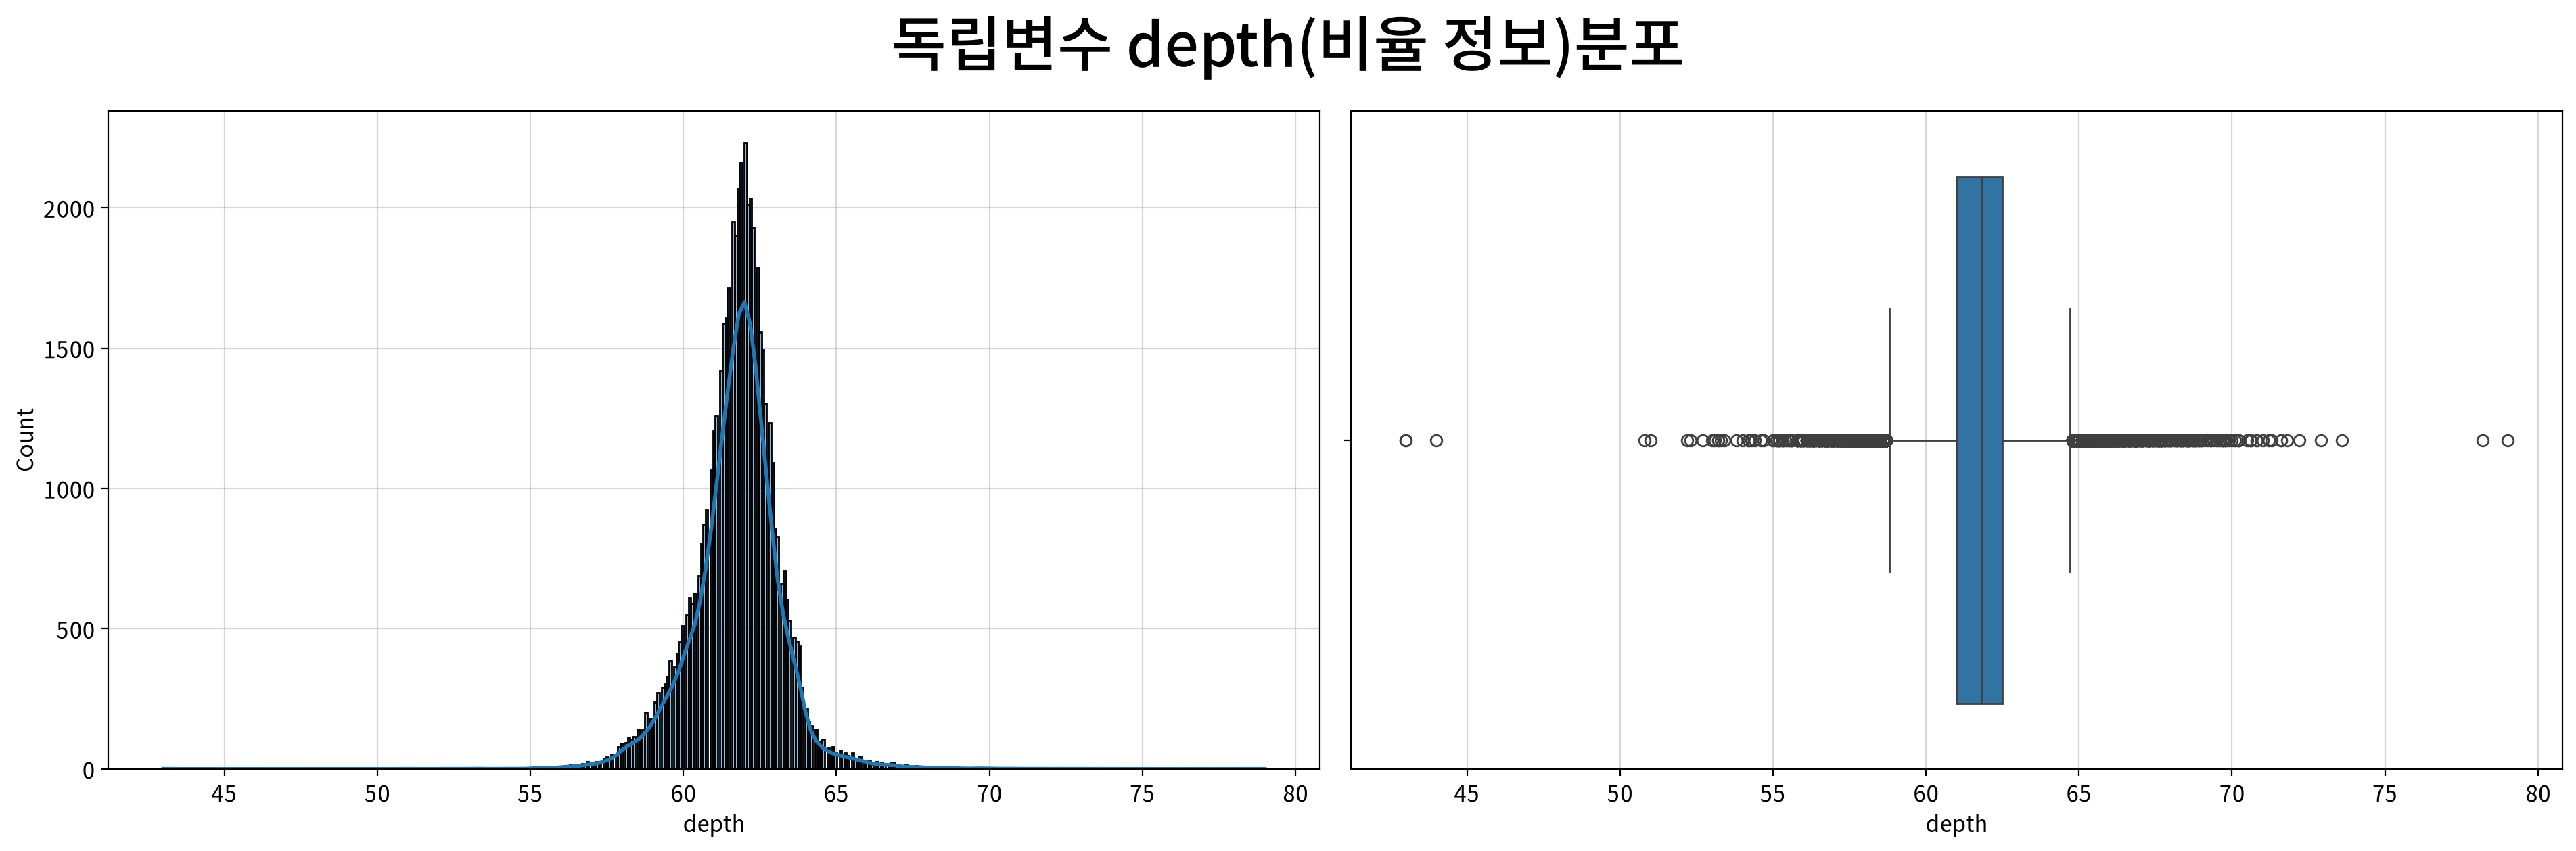

,depth
count,53794.000
mean,61.748
std,1.430
min,43.000
25%,61.000
50%,61.800
75%,62.500
max,79.000
rel_diff,0.001
rdiff_flag,similar


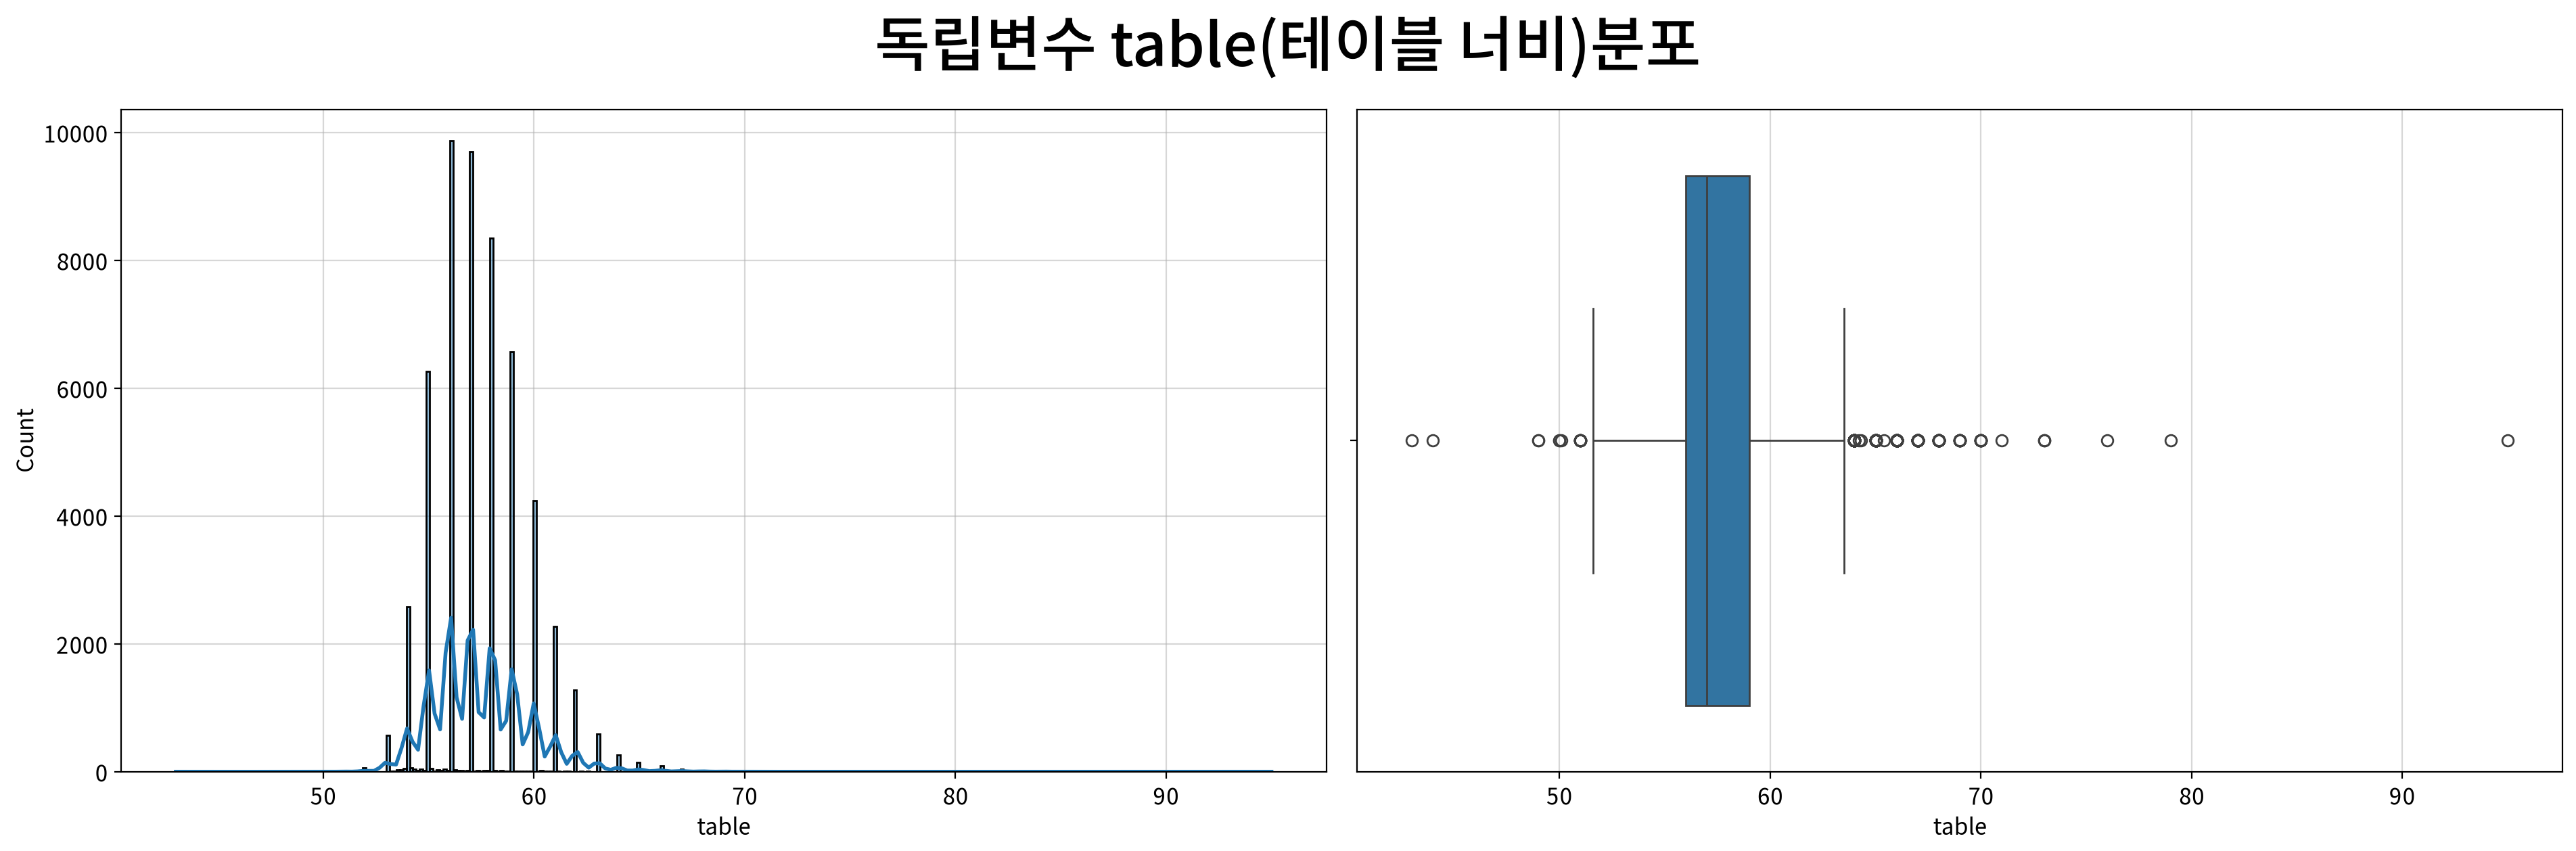

,table
count,53794.000
mean,57.458
std,2.234
min,43.000
25%,56.000
50%,57.000
75%,59.000
max,95.000
rel_diff,0.008
rdiff_flag,similar


In [13]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640, 
                           title=f"독립변수 {f}({column_means[f]})분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

## #02. 단변량 분석 

### 3. 명목형 독립변수에 대한 단변량 분석 

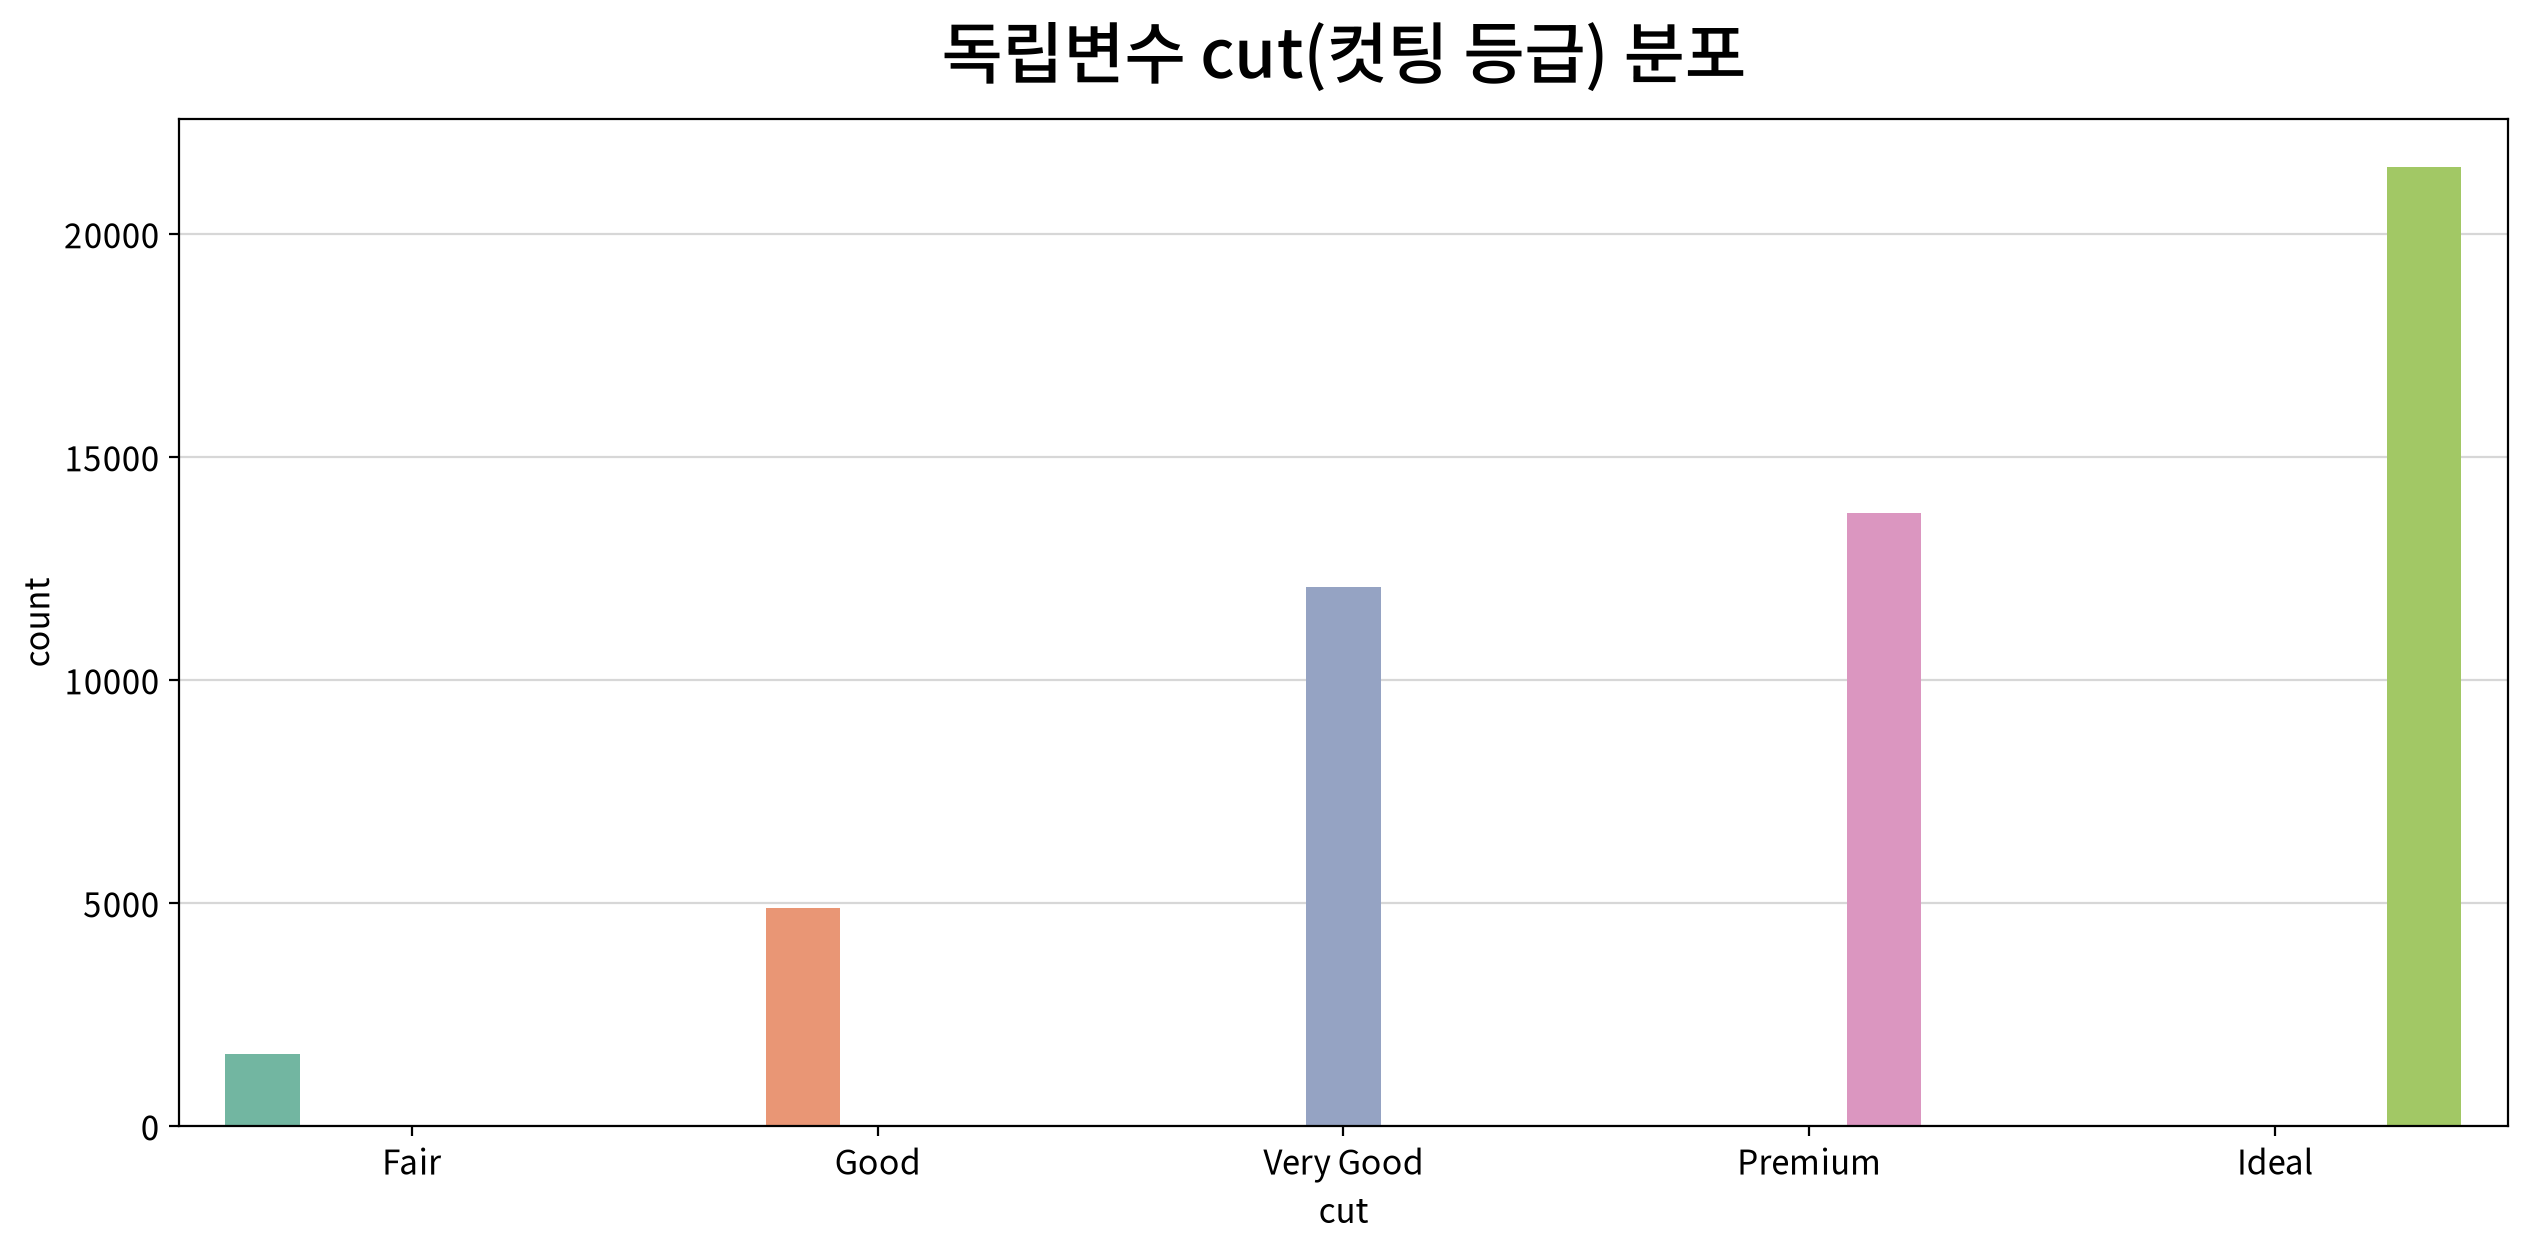

,count,unique,top,freq
cut,53794,5,Ideal,21488


,빈도,비율
cut,,
Ideal,21488,0.399
Premium,13748,0.256
Very Good,12069,0.224
Good,4891,0.091
Fair,1598,0.030


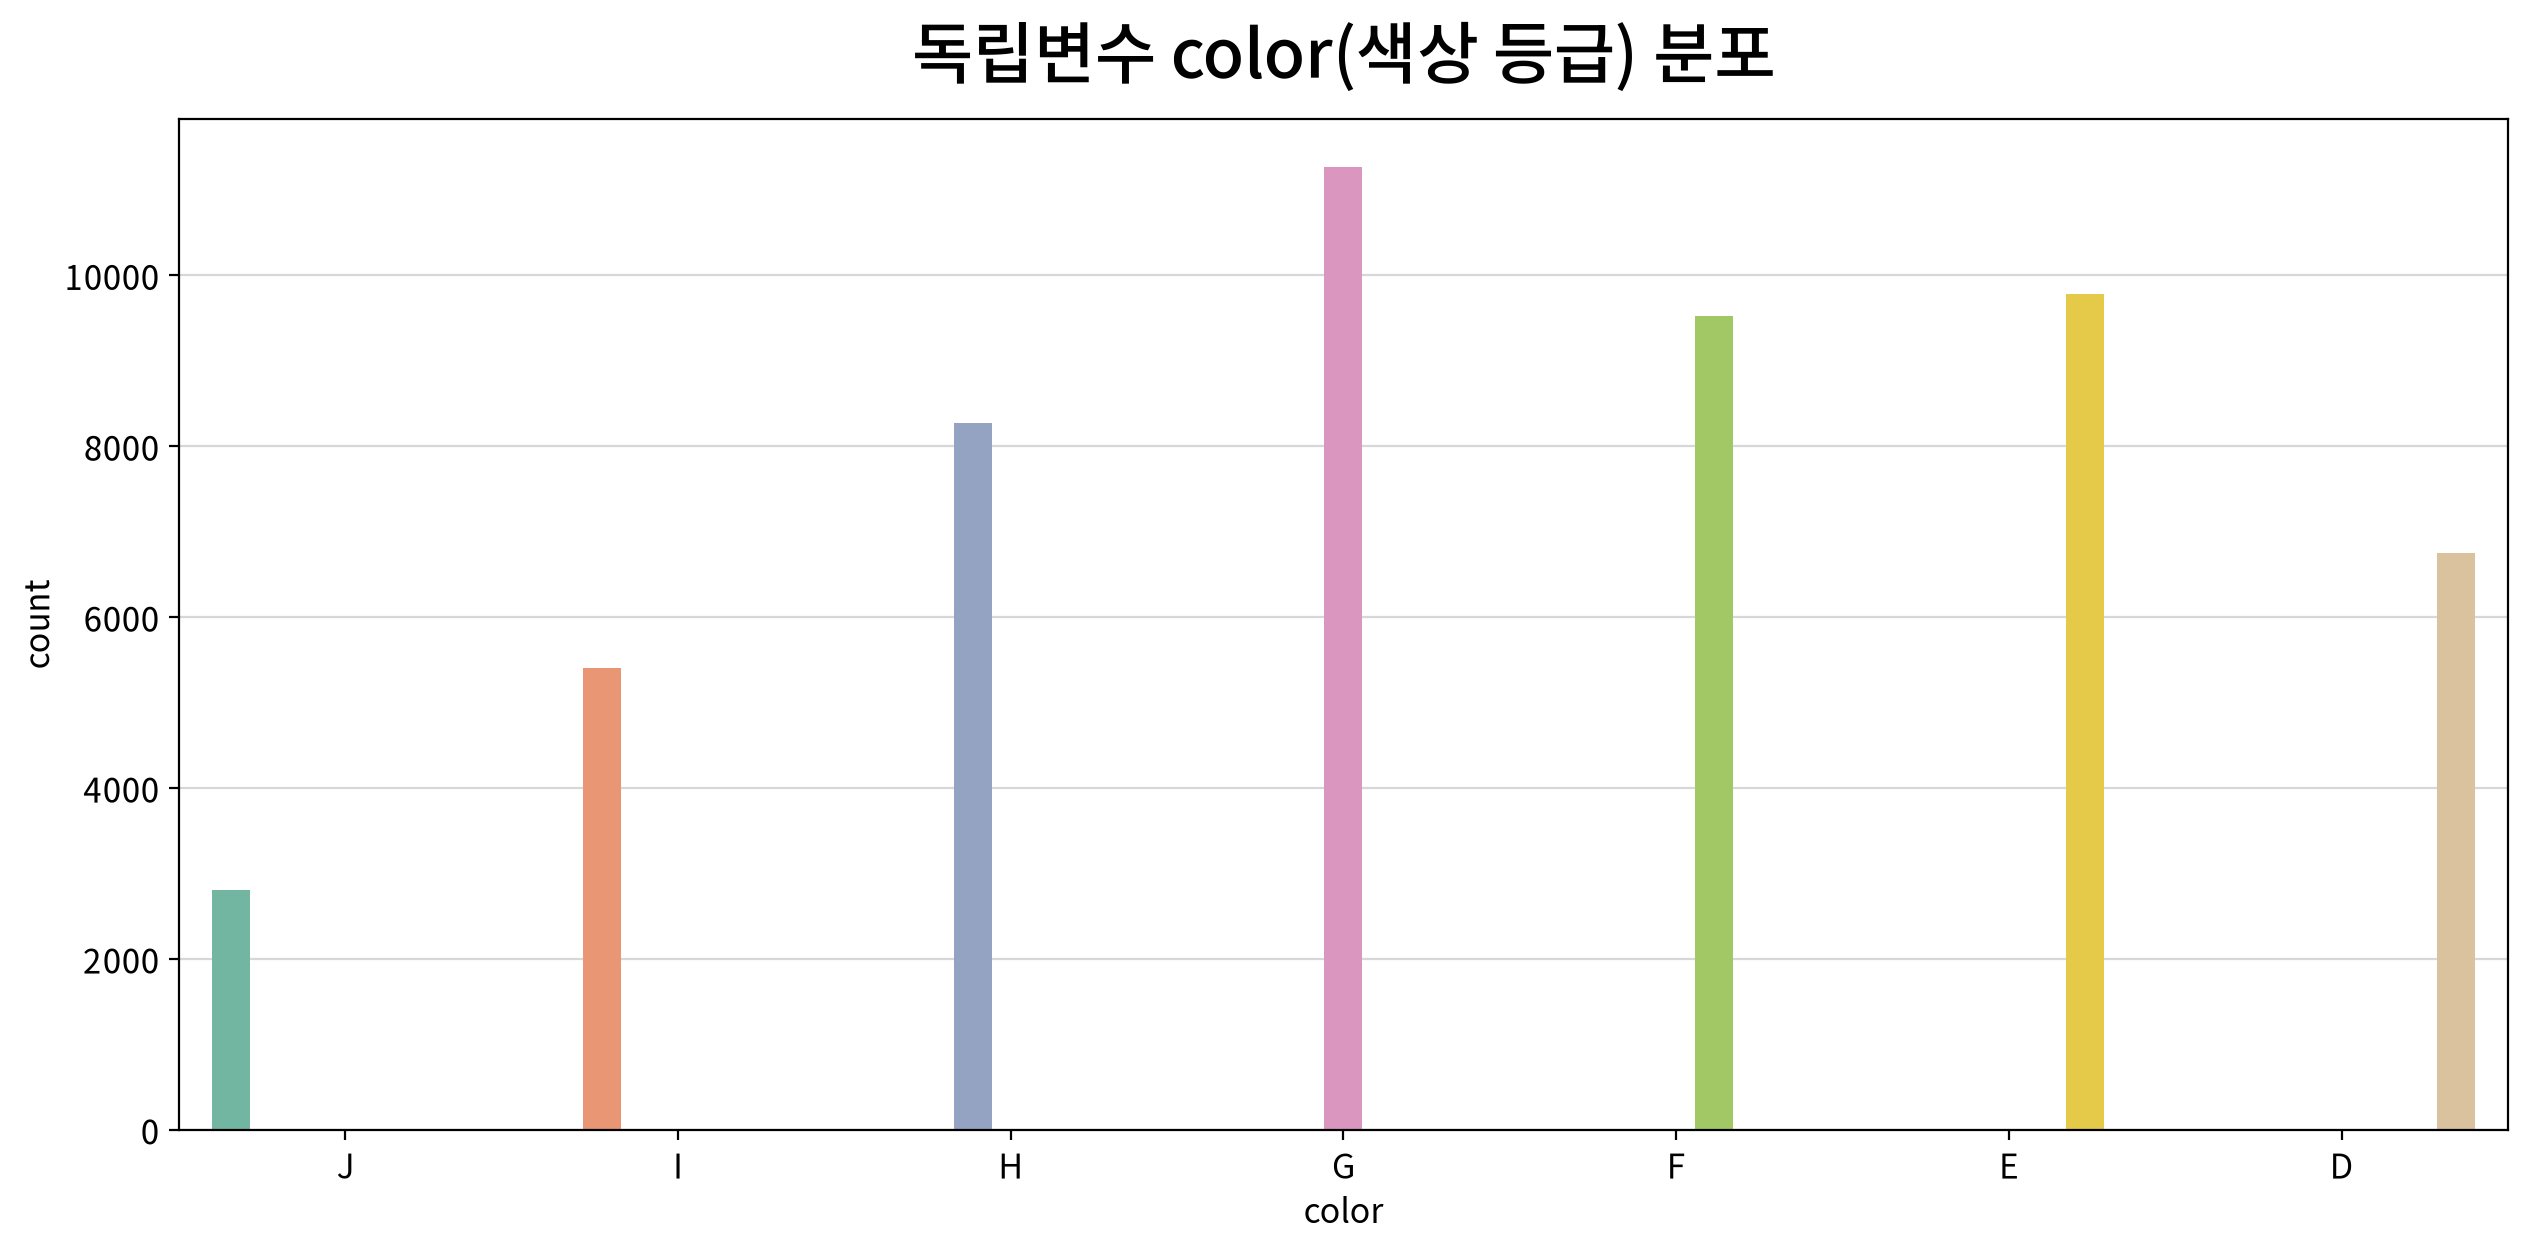

,count,unique,top,freq
color,53794,7,G,11262


,빈도,비율
color,,
G,11262,0.209
E,9776,0.182
F,9520,0.177
H,8272,0.154
D,6755,0.126
I,5407,0.101
J,2802,0.052


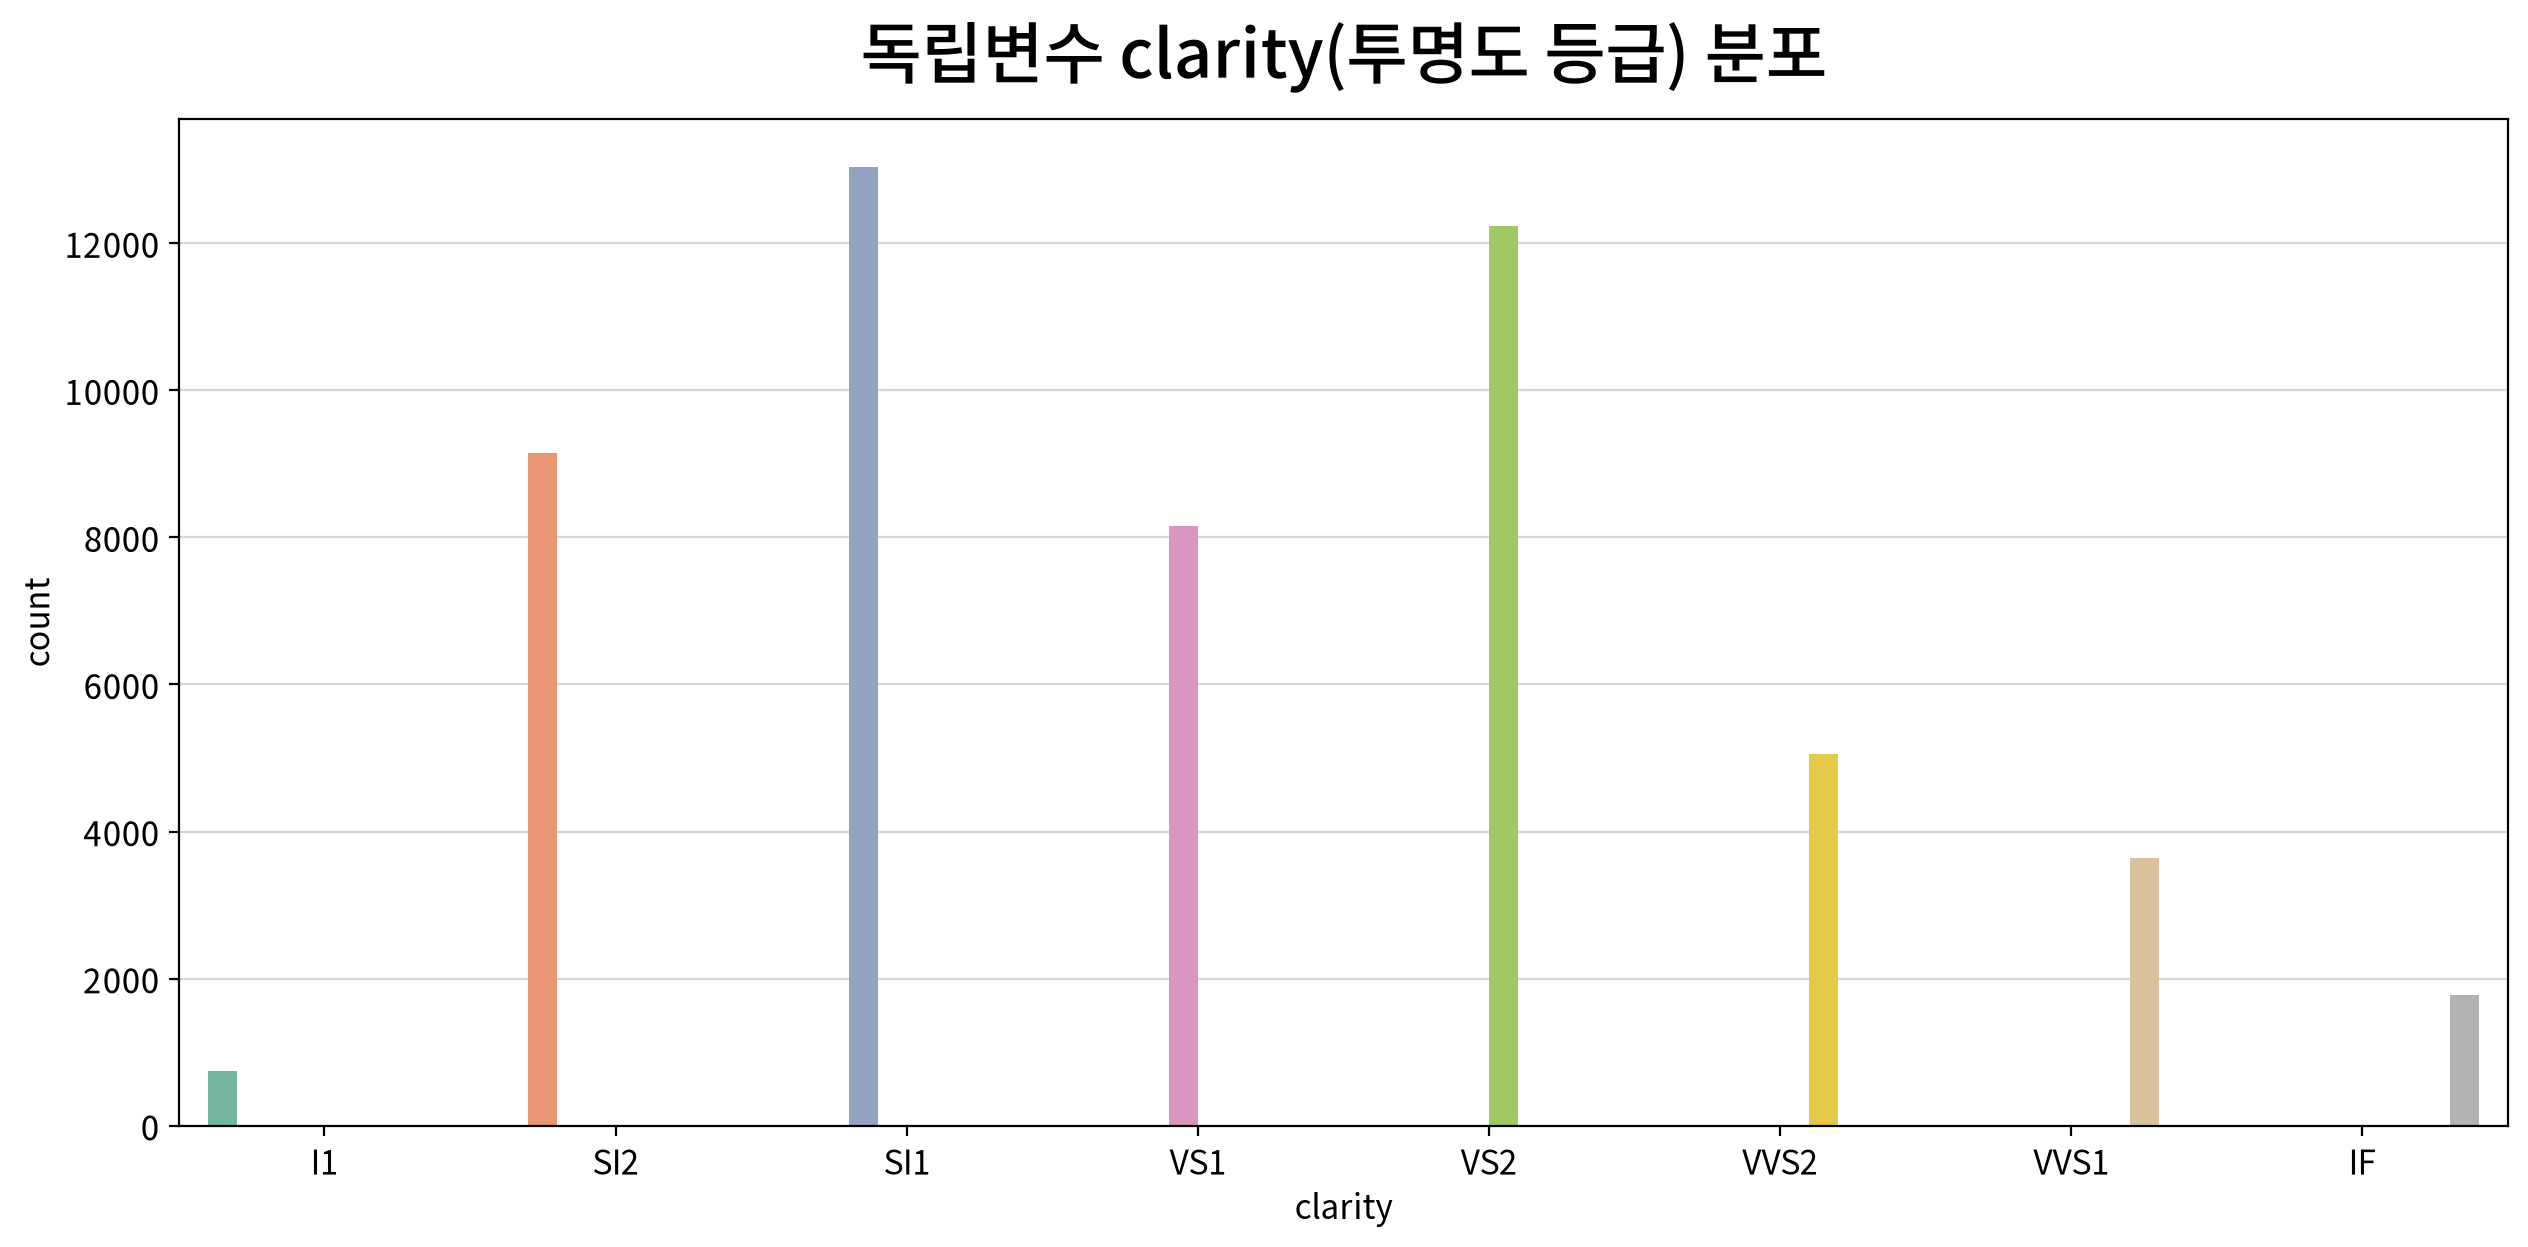

,count,unique,top,freq
clarity,53794,8,SI1,13032


,빈도,비율
clarity,,
SI1,13032,0.242
VS2,12229,0.227
SI2,9150,0.170
VS1,8156,0.152
VVS2,5056,0.094
VVS1,3647,0.068
IF,1784,0.033
I1,740,0.014


In [15]:
for n in nominal_cols: 
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", 
                      title=f"독립변수 {n}({column_means[n]}) 분포")
    
    # 명목형 기술 통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성 
    freq = df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산 
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

## #03. 이변량 분석 

### 1. 상관분석 (x:연속형 독립변수 -> y:연속형 종속변수)

#### -> carat(중량) -> price

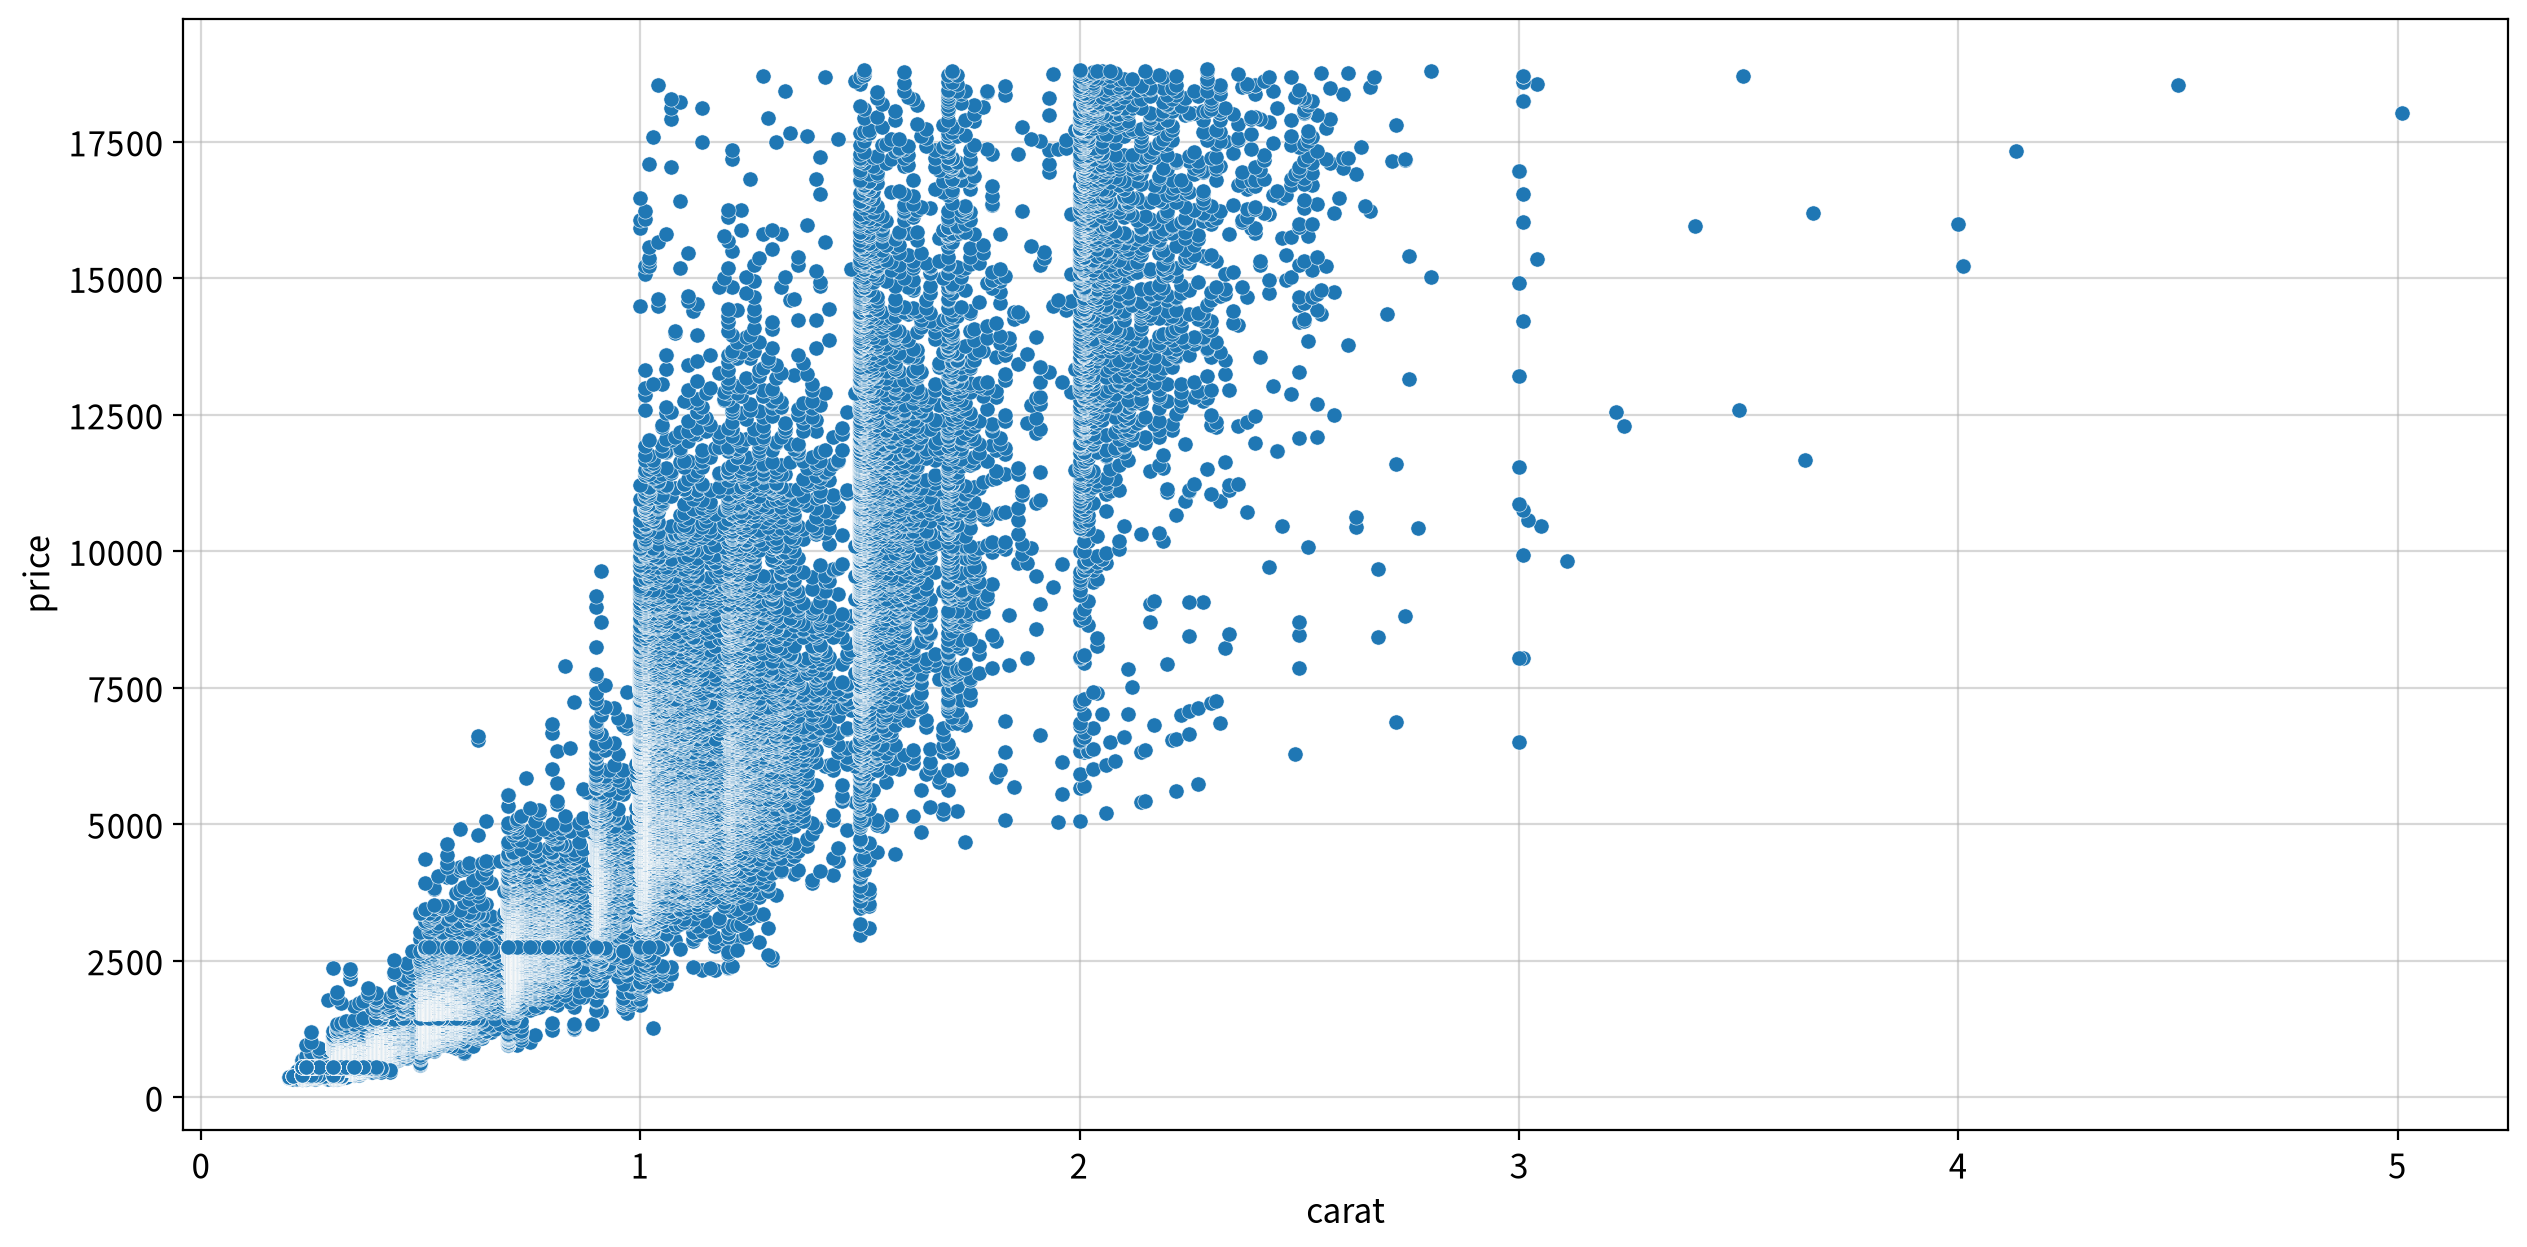

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
carat,price,Spearman,0.963,0.000,Strong,False,False,False,False,True


#### -> x(길이(mm)) -> price

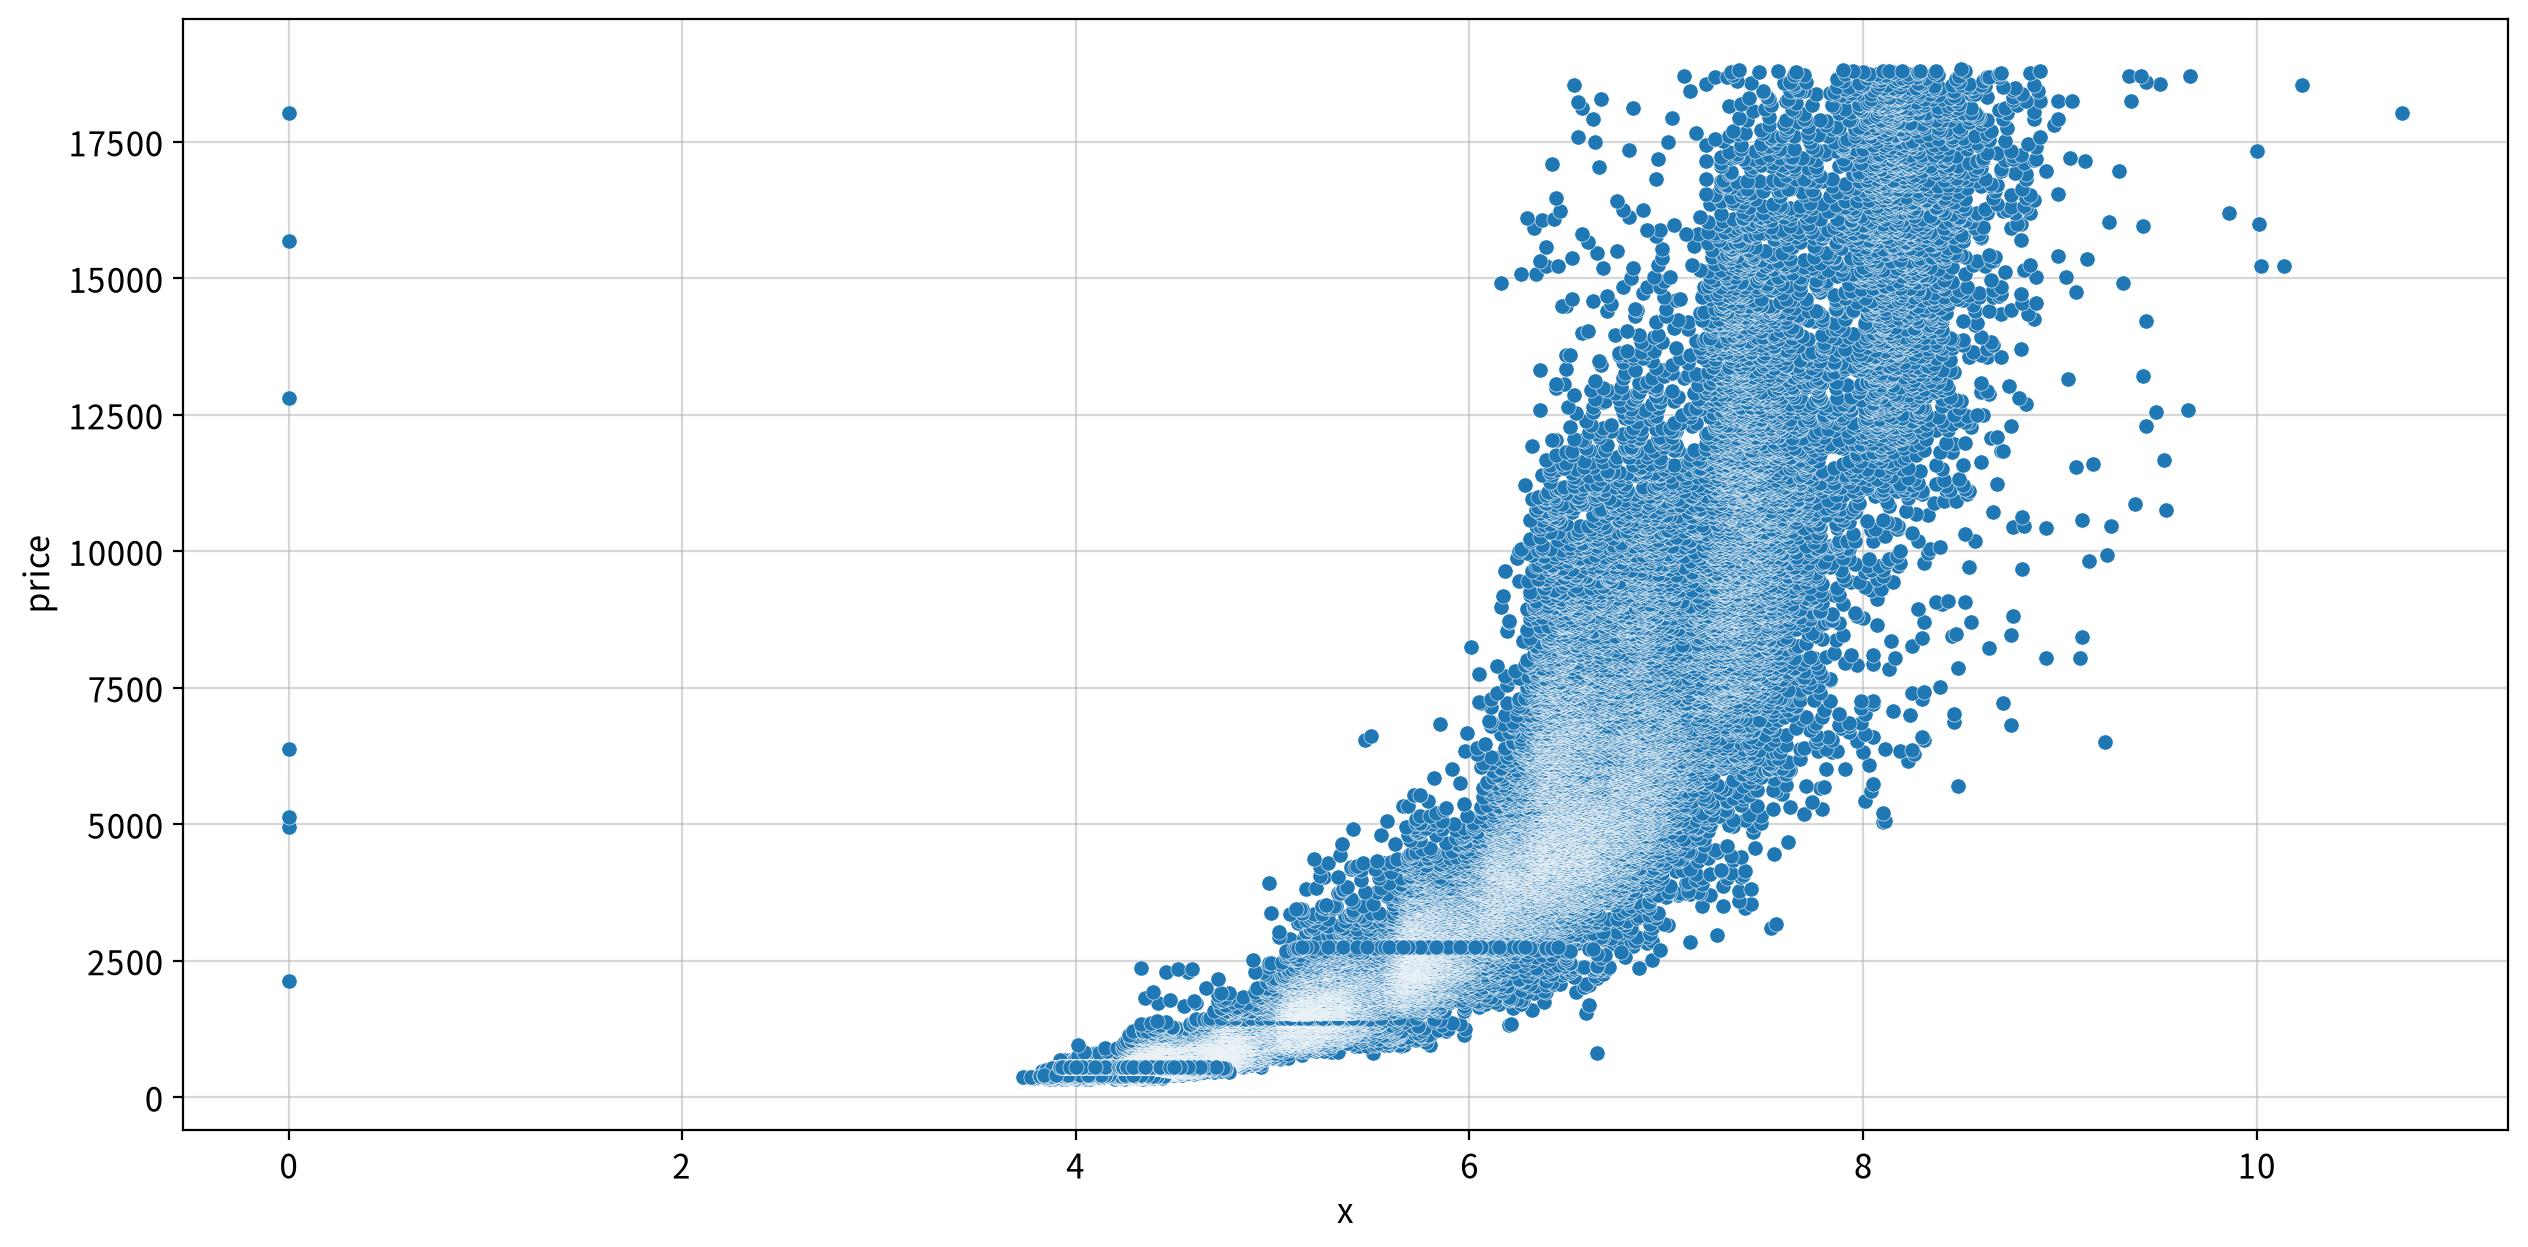

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
x,price,Spearman,0.963,0.000,Strong,False,False,False,False,True


#### -> y(너비 (mm)) -> price

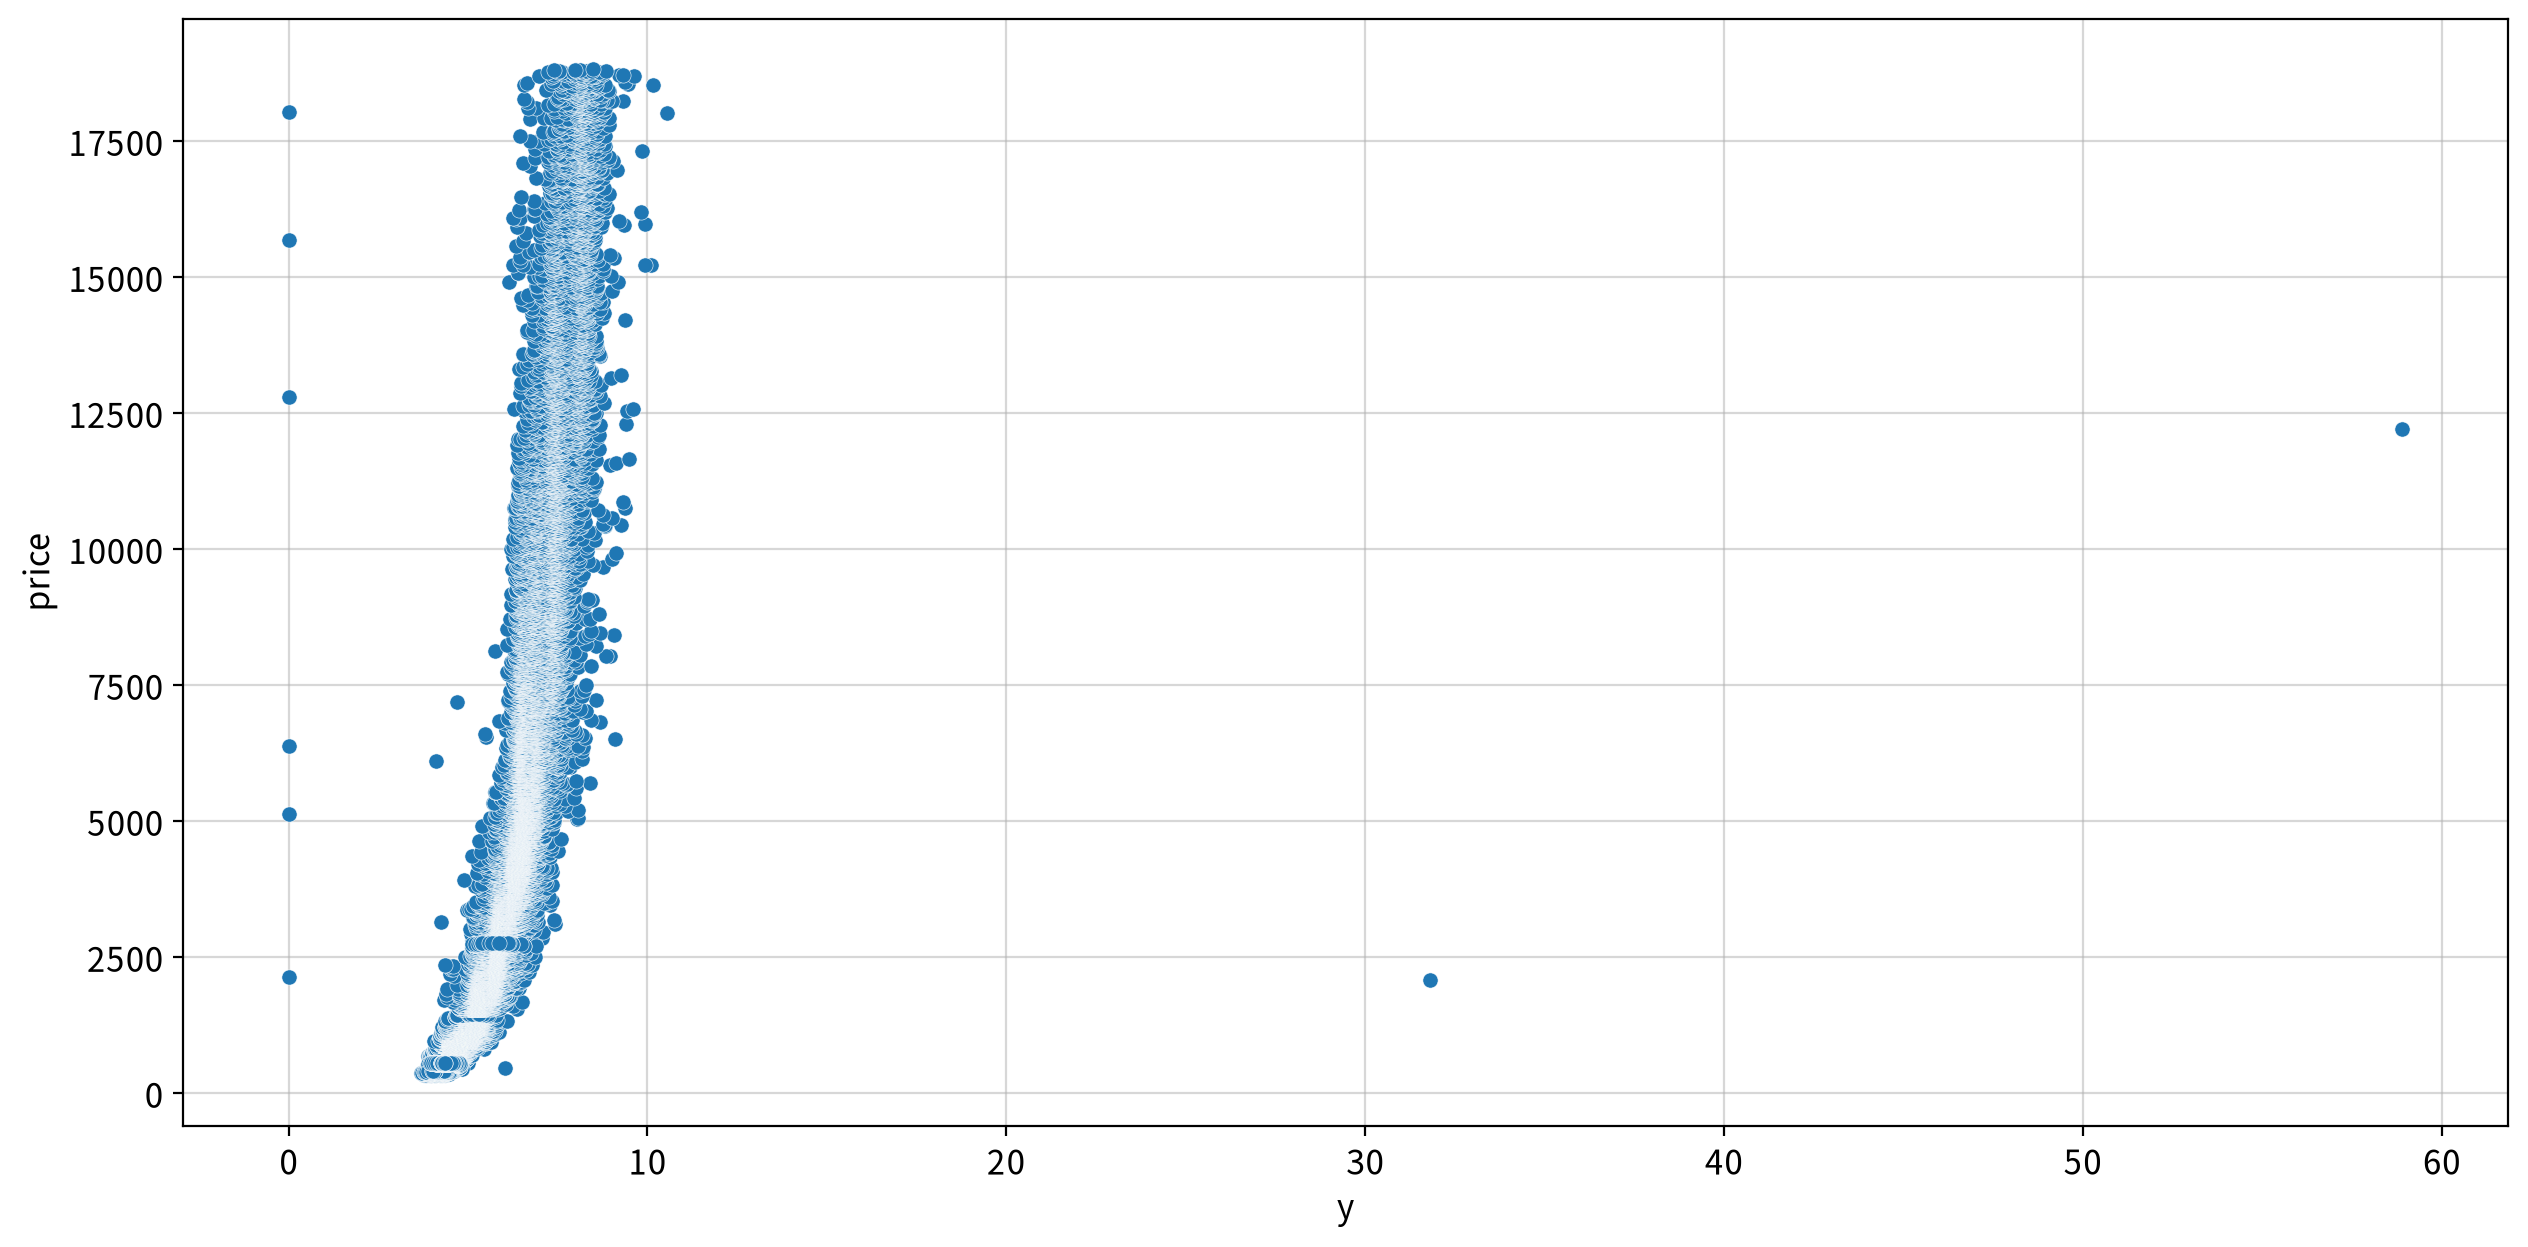

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
y,price,Spearman,0.963,0.000,Strong,False,False,False,False,True


#### -> z(두께 (mm)) -> price

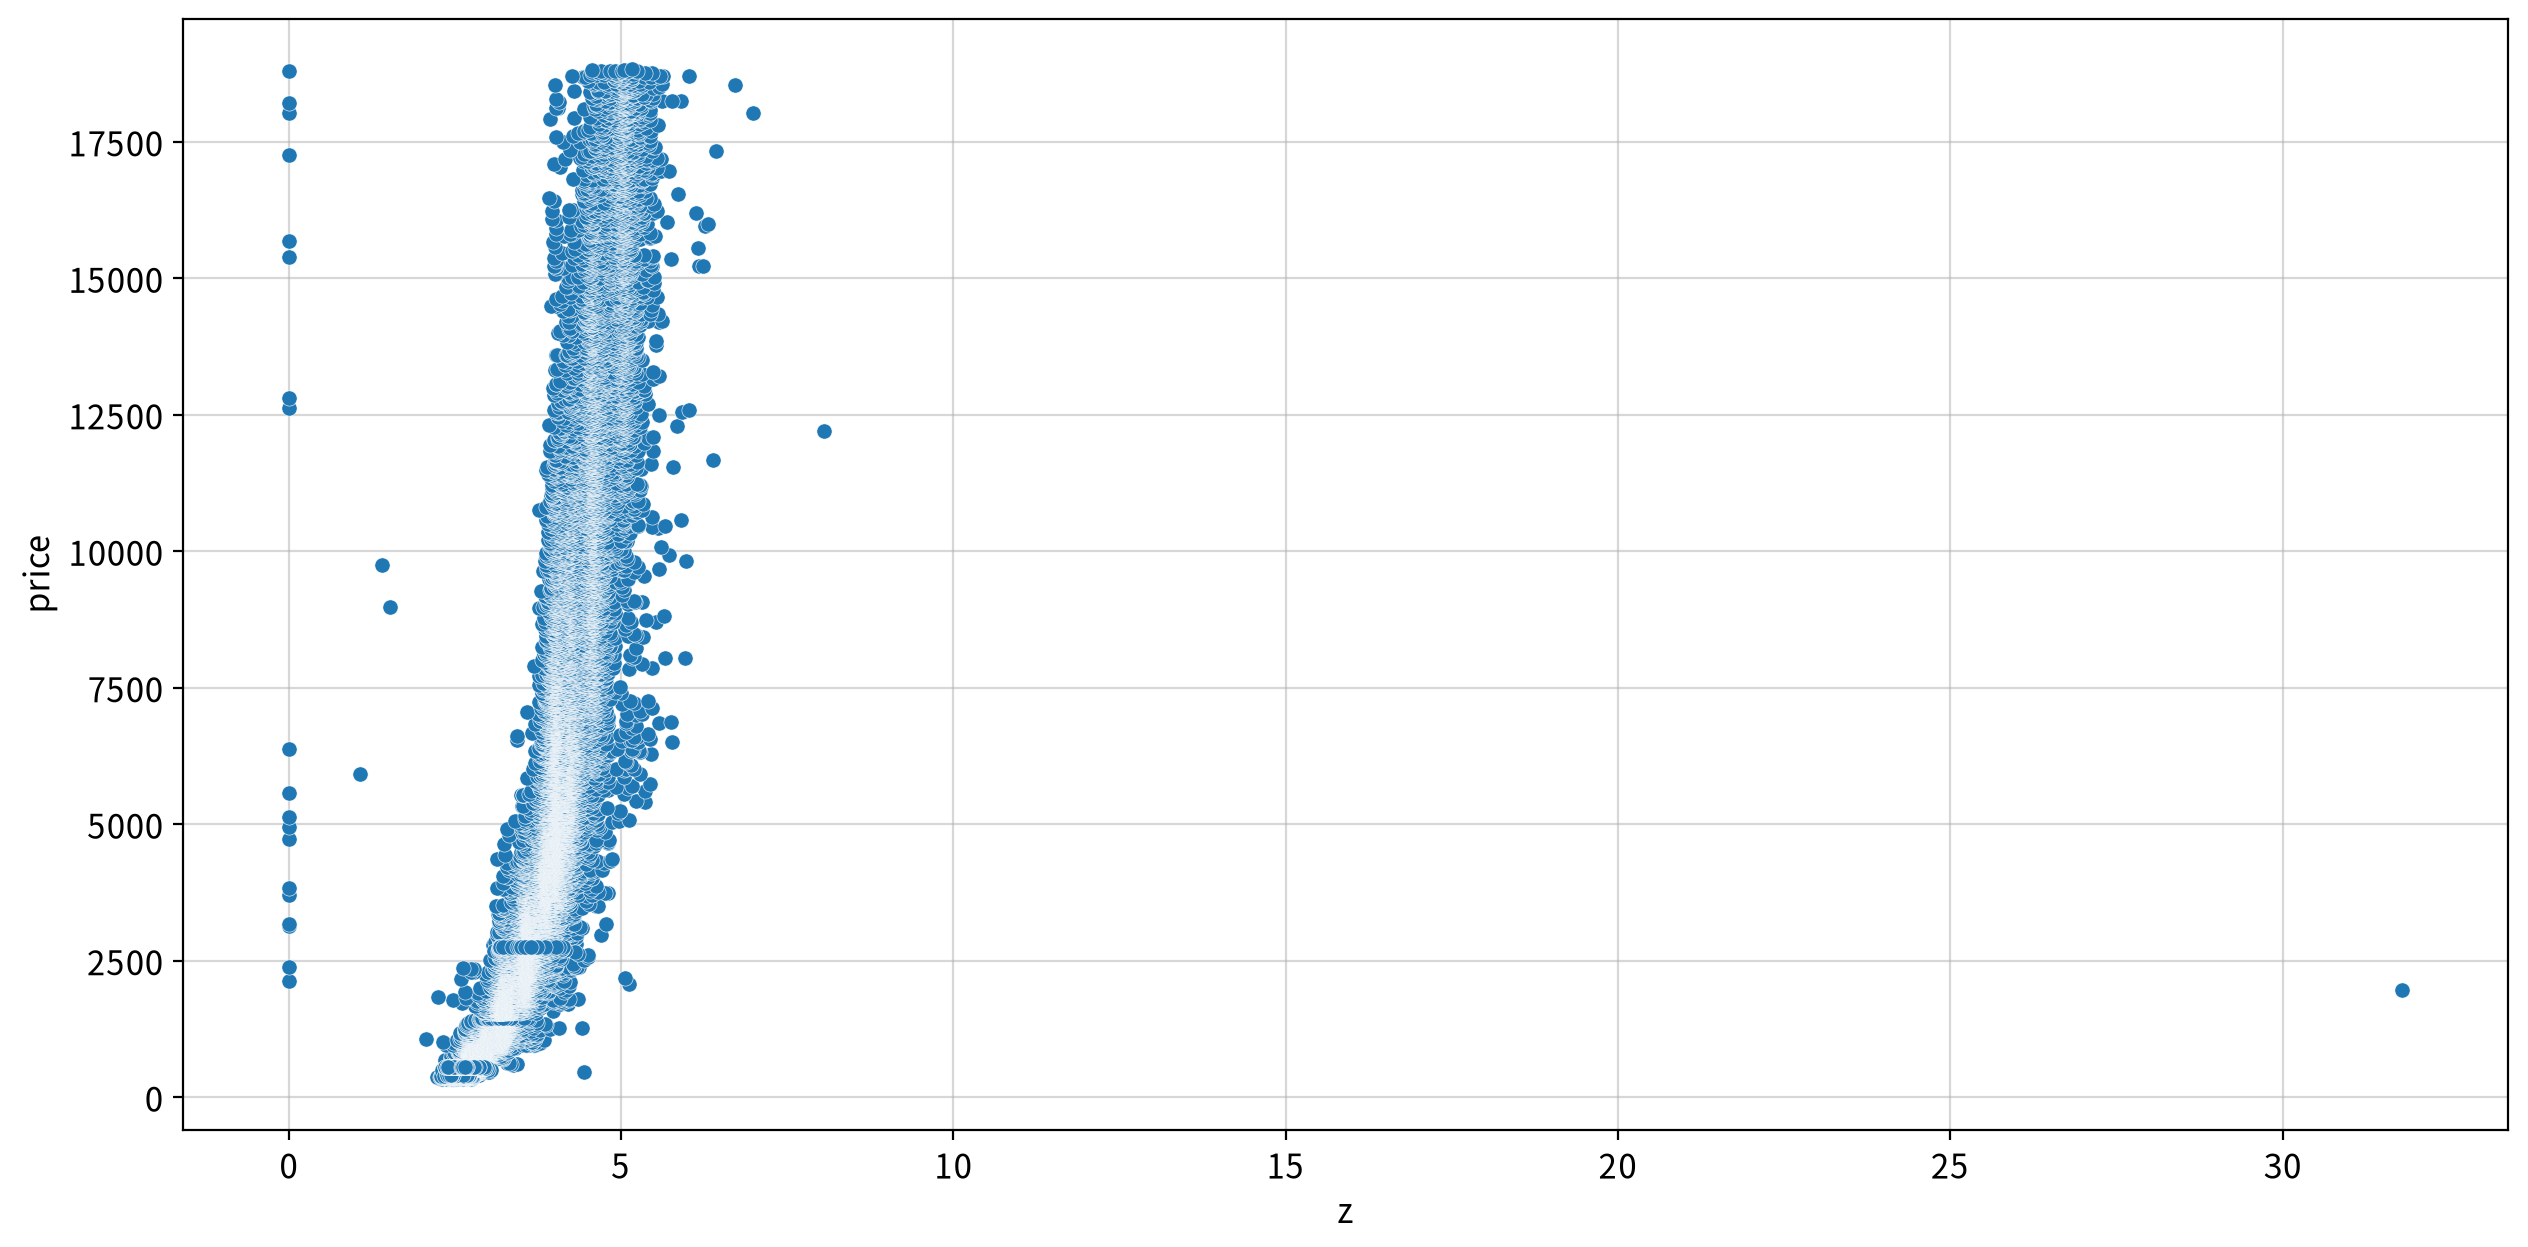

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
z,price,Spearman,0.957,0.000,Strong,False,False,False,False,True


#### -> depth(비율 정보) -> price

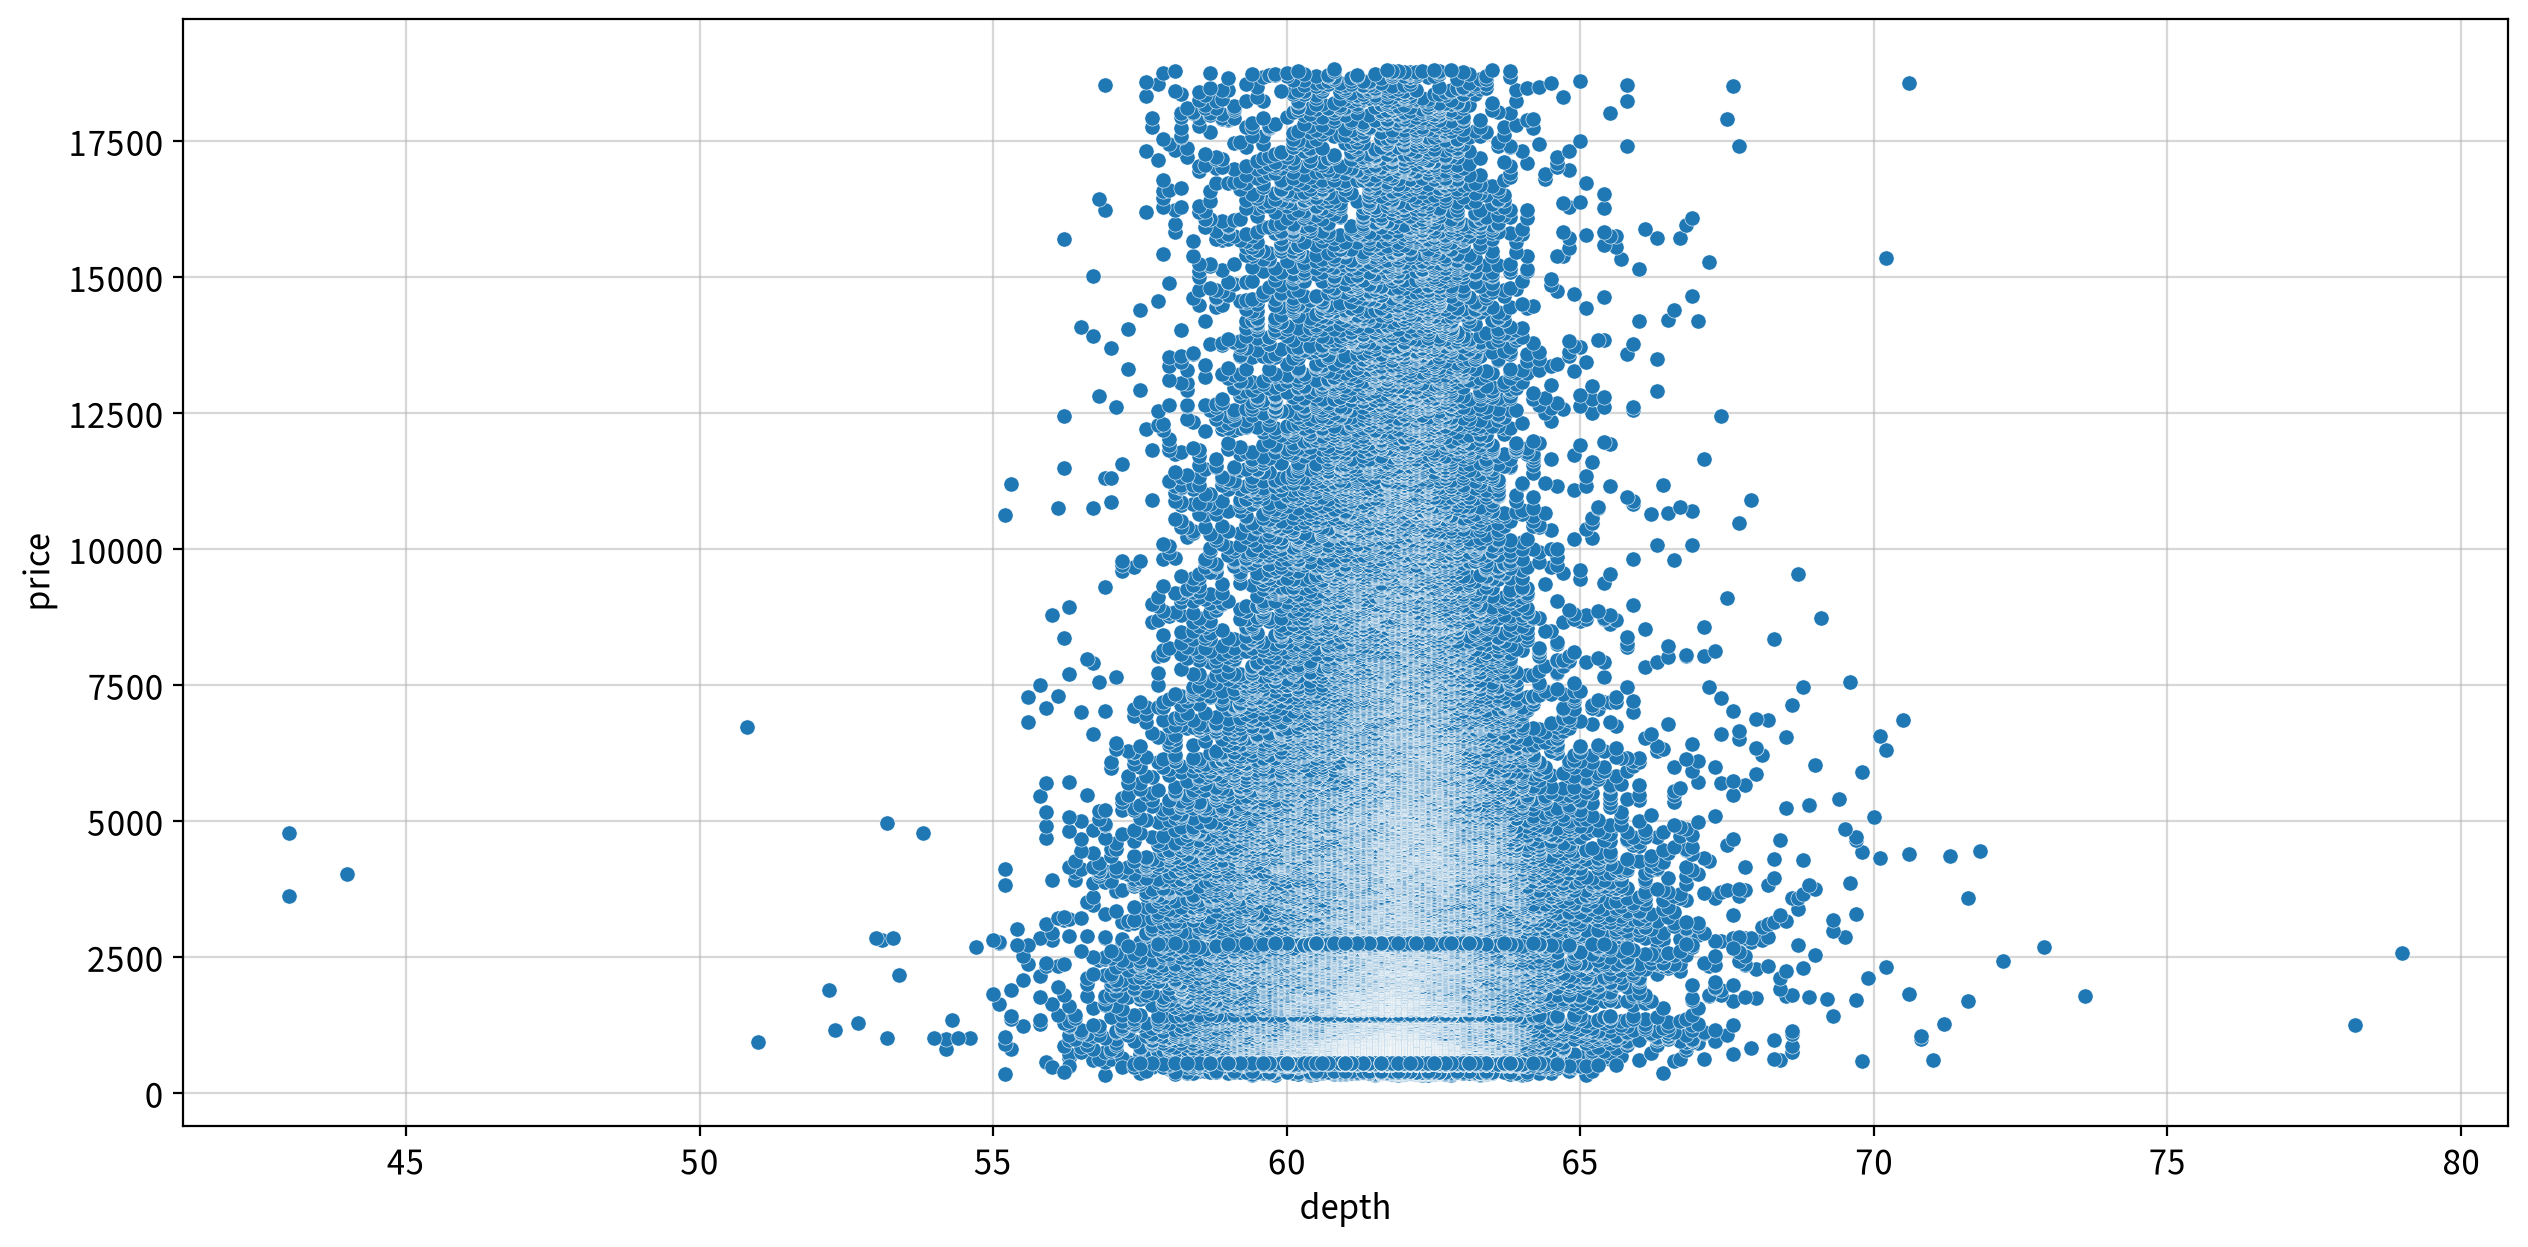

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
depth,price,Spearman,0.010,0.018,Weak,False,False,False,False,True


#### -> table(테이블 너비) -> price

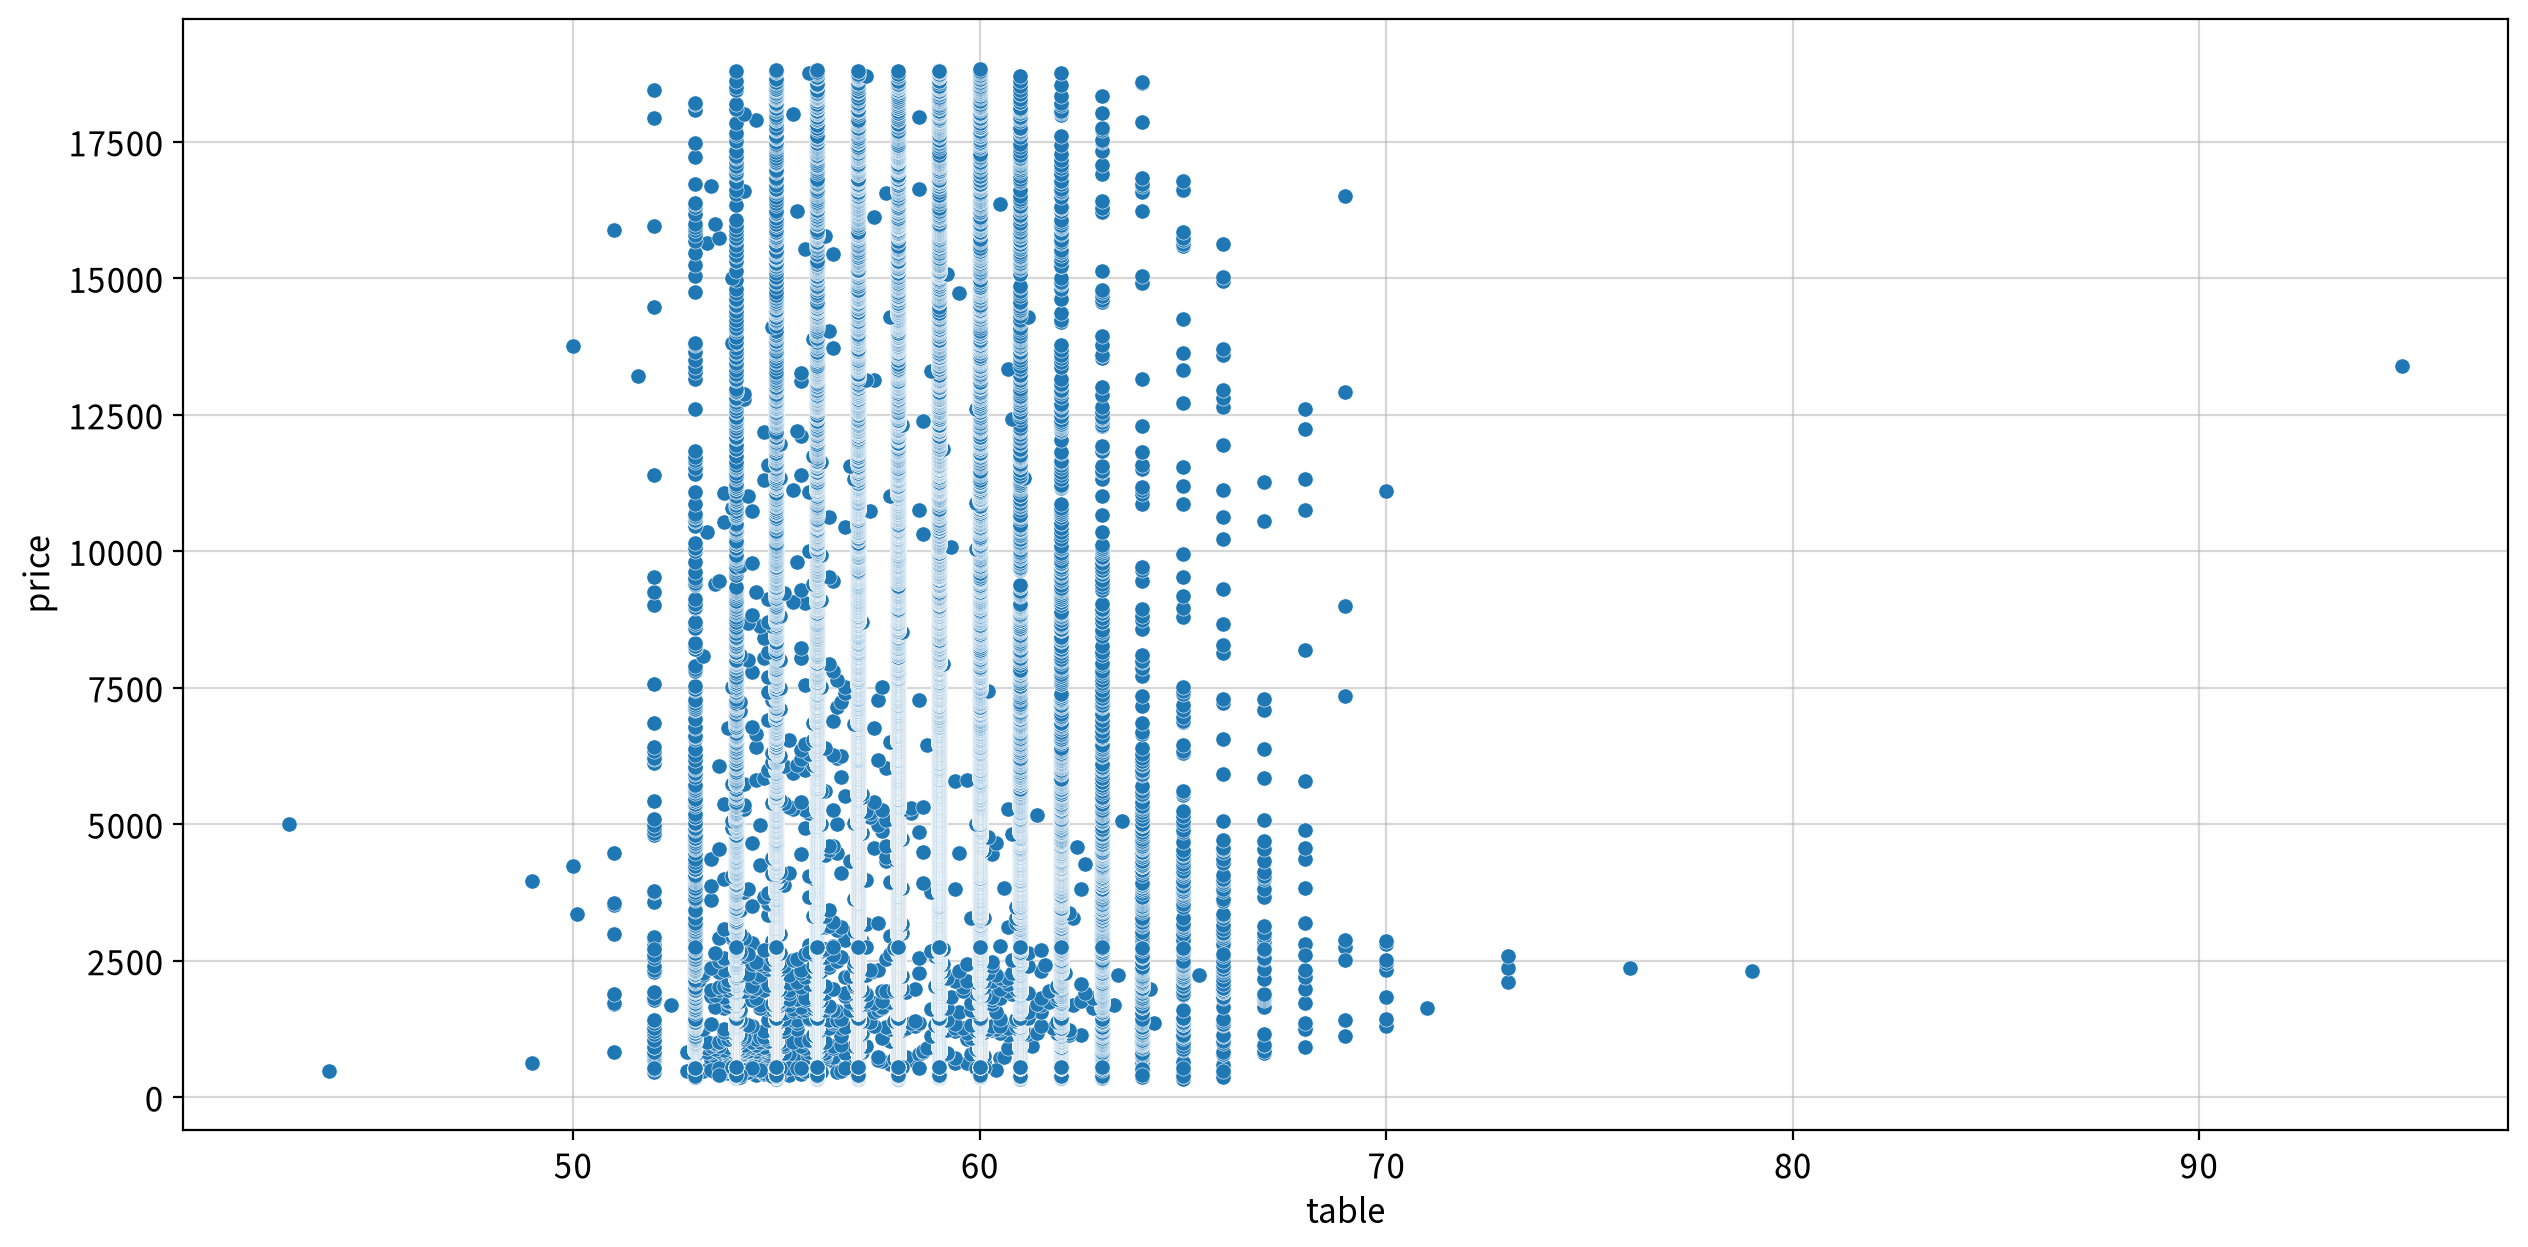

,,method,coef,p-value,strength,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,
table,price,Spearman,0.171,0.000,Weak,False,False,False,False,True


In [16]:
# 연속형 독립변수 이름을 탐색하면서 반복 
for f in continuous_cols:
    # 빈 줄 출력용 
    print()

    # 분석 단위 제목 출력 
    display(Markdown(f"#### -> {f}({column_means[f]}) -> {target}"))

    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False, 
                        # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
                        linewidth = 0.2, size=30 )
    
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

### 2. T-Test (x:2집단 명목형 독립변수 -> y:종속변수)

In [17]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) ==2:
        # 빈 줄 출력용 
        print()

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                                          group1=wide_df.columns[0], group2=wide_df.columns[1]))    

### 3. ANOVA (x:3집단 명목형 독립변수 -> y:종속변수)

In [18]:
for n in nominal_cols: 
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용 

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df, y=target, between=n))

        # 사후검정 
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### -> cut(컷팅 등급) -> price

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,cut,4,9347.505,163.115,0.000,0.013,Small


비교한 조합 쌍: 10개
유의한 쌍: 8개
평균 차이가 가장 큰 쌍: (Premium) vs (Ideal)-> 차이 1120.752, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (Good) vs (Very Good)-> 차이 61.895, 효과크기 Negligible, p-value 0.867


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,Fair,Good,4341.954,3919.121,422.833,102.947,4.107,2803.307,0.000,0.116,True,Negligible
1,Games-Howell,Fair,Very Good,4341.954,3981.016,360.938,95.527,3.778,2154.562,0.002,0.093,True,Negligible
2,Games-Howell,Fair,Premium,4341.954,4583.502,-241.548,96.009,-2.516,2198.298,0.087,-0.057,False,Negligible
3,Games-Howell,Fair,Ideal,4341.954,3462.750,879.204,92.295,9.526,1883.080,0.000,0.232,True,Small
4,Games-Howell,Good,Very Good,3919.121,3981.016,-61.895,63.547,-0.974,9655.235,0.867,-0.016,False,Negligible
5,Games-Howell,Good,Premium,3919.121,4583.502,-664.381,64.270,-10.337,10094.516,0.000,-0.159,True,Negligible
6,Games-Howell,Good,Ideal,3919.121,3462.750,456.371,58.577,7.791,7480.705,0.000,0.121,True,Negligible
7,Games-Howell,Very Good,Premium,3981.016,4583.502,-602.486,51.556,-11.686,25791.196,0.000,-0.145,True,Negligible
8,Games-Howell,Very Good,Ideal,3981.016,3462.750,518.266,44.257,11.710,24339.407,0.000,0.134,True,Negligible
9,Games-Howell,Premium,Ideal,4583.502,3462.750,1120.752,45.288,24.747,26487.259,0.000,0.278,True,Small


#### -> color(색상 등급) -> price

...

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,J,I,5326.415,5081.751,244.664,105.505,2.319,5984.153,0.235,0.053,False,Negligible
1,Games-Howell,J,H,5326.415,4482.855,843.560,95.705,8.814,4627.927,0.000,0.198,True,Negligible
2,Games-Howell,J,G,5326.415,4001.352,1325.063,92.050,14.395,4042.238,0.000,0.321,True,Small
3,Games-Howell,J,F,5326.415,3726.750,1599.666,92.313,17.329,4077.359,0.000,0.406,True,Small
4,Games-Howell,J,E,5326.415,3079.608,2246.807,90.340,24.870,3761.771,0.000,0.621,True,Medium
5,Games-Howell,J,D,5326.415,3174.441,2151.974,93.200,23.090,4195.115,0.000,0.581,True,Medium
6,Games-Howell,I,H,5081.751,4482.855,598.896,79.115,7.570,10621.023,0.000,0.136,True,Negligible
7,Games-Howell,I,G,5081.751,4001.352,1080.399,74.652,14.472,9349.895,0.000,0.252,True,Small
8,Games-Howell,I,F,5081.751,3726.750,1355.002,74.977,18.072,9373.617,0.000,0.327,True,Small
9,Games-Howell,I,E,5081.751,3079.608,2002.143,72.534,27.603,8471.695,0.000,0.515,True,Medium


#### -> clarity(투명도 등급) -> price

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,clarity,7,8541.969,221.943,0.000,0.027,Small


비교한 조합 쌍: 28개
유의한 쌍: 22개
평균 차이가 가장 큰 쌍: (SI2) vs (VVS1)-> 차이 2530.852, 효과크기 Medium, p-value 0.000
평균 차이가 가장 작은 쌍: (I1) vs (VS2)-> 차이 2.466, 효과크기 Negligible, p-value 1.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,I1,SI2,3925.276,5057.455,-1132.180,112.419,-10.071,1035.965,0.000,-0.272,True,Small
1,Games-Howell,I1,SI1,3925.276,3996.165,-70.889,108.475,-0.654,900.022,0.998,-0.019,False,Negligible
2,Games-Howell,I1,VS1,3925.276,3841.611,83.664,112.392,0.744,1034.654,0.996,0.021,False,Negligible
3,Games-Howell,I1,VS2,3925.276,3927.742,-2.466,109.522,-0.023,934.950,1.000,-0.001,False,Negligible
4,Games-Howell,I1,VVS2,3925.276,3286.532,638.743,116.406,5.487,1181.572,0.000,0.172,True,Negligible
5,Games-Howell,I1,VVS1,3925.276,2526.603,1398.673,117.105,11.944,1203.205,0.000,0.430,True,Small
6,Games-Howell,I1,IF,3925.276,2870.570,1054.706,138.914,7.593,1903.846,0.000,0.290,True,Small
7,Games-Howell,SI2,SI1,5057.455,3996.165,1061.290,55.556,19.103,18244.784,0.000,0.266,True,Small
8,Games-Howell,SI2,VS1,5057.455,3841.611,1215.844,62.862,19.342,17249.862,0.000,0.294,True,Small
9,Games-Howell,SI2,VS2,5057.455,3927.742,1129.714,57.573,19.622,19143.587,0.000,0.273,True,Small


## #04. 다변량 분석 

### 1. 독립변수간 상관분석 

In [19]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,carat,x,y,z,depth,table
carat,1.000,0.996,0.996,0.993,0.030,0.194
x,0.996,1.000,0.998,0.987,-0.023,0.202
y,0.996,0.998,1.000,0.987,-0.025,0.195
z,0.993,0.987,0.987,1.000,0.104,0.159
depth,0.030,-0.023,-0.025,0.104,1.000,-0.245
table,0.194,0.202,0.195,0.159,-0.245,1.000


,max-y,max-coef,count,columns
x,,,,
x,y,0.998,3,"y, carat, z"
y,x,0.998,3,"x, carat, z"
carat,x,0.996,3,"x, y, z"
z,carat,0.993,3,"carat, x, y"
depth,table,-0.245,0,-
table,depth,-0.245,0,-
